# setting

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import OneHotEncoder
from collections import Counter

# for model evaluation
from sklearn.metrics import accuracy_score # モデル評価用(正答率)
from sklearn.metrics import log_loss # モデル評価用(logloss)     
from sklearn.metrics import roc_auc_score # モデル評価用(auc)
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# visualize
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import warnings
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
warnings.simplefilter('ignore')

# data preparation

In [3]:
# load training data
train_data = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')

In [4]:
# log transform
log_vars = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for log_var in log_vars:
    train_data[log_var + '_log'] = [np.log1p(x) for x in train_data[log_var]]
    
for log_var in log_vars:
    test_data[log_var + '_log'] = [np.log1p(x) for x in test_data[log_var]]

In [5]:
# data imputation
# in this section blank data for luxuary services are imputed with some rules/

# impute by CryoSleep
# If 'CryoSleep' is True, services must be zero because passengers in cryosleep need not to take services.
train_data.loc[(train_data['CryoSleep']==True) & (train_data['RoomService'].isnull()), 'RoomService'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['Spa'].isnull()), 'Spa'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['VRDeck'].isnull()), 'VRDeck'] = 0

test_data.loc[(test_data['CryoSleep']==True) & (test_data['RoomService'].isnull()), 'RoomService'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['Spa'].isnull()), 'Spa'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['VRDeck'].isnull()), 'VRDeck'] = 0

# impute by Age
# If 'Age' is under 13, services must be zero because of age limitation.
train_data.loc[(train_data['Age']<13) & (train_data['RoomService'].isnull()), 'RoomService'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['Spa'].isnull()), 'Spa'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['VRDeck'].isnull()), 'VRDeck'] = 0

test_data.loc[(test_data['Age']<13) & (test_data['RoomService'].isnull()), 'RoomService'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['Spa'].isnull()), 'Spa'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['VRDeck'].isnull()), 'VRDeck'] = 0

In [6]:
# add service summ
train_data['ServiceSum'] = np.array(train_data['RoomService']) + \
                           np.array(train_data['FoodCourt']) + \
                           np.array(train_data['ShoppingMall']) + \
                           np.array(train_data['Spa']) + \
                           np.array(train_data['VRDeck'])

test_data['ServiceSum'] = np.array(test_data['RoomService']) + \
                           np.array(test_data['FoodCourt']) + \
                           np.array(test_data['ShoppingMall']) + \
                           np.array(test_data['Spa']) + \
                           np.array(test_data['VRDeck'])

In [7]:
# create new features based on luxuary services
train_data['RoomService_bool'] = train_data['RoomService']>0
train_data['FoodCourt_bool'] = train_data['FoodCourt']>0
train_data['ShoppingMall_bool'] = train_data['ShoppingMall']>0
train_data['Spa_bool'] = train_data['Spa']>0
train_data['VRDeck_bool'] = train_data['VRDeck']>0
train_data['num_services'] = np.array(train_data['RoomService_bool']).astype(int) + \
                                 np.array(train_data['FoodCourt_bool']).astype(int) + \
                                 np.array(train_data['ShoppingMall_bool']).astype(int) + \
                                 np.array(train_data['Spa_bool']).astype(int) + \
                                 np.array(train_data['VRDeck_bool']).astype(int)
train_data['services_bool'] = train_data['num_services']>0

test_data['RoomService_bool'] = test_data['RoomService']>0
test_data['FoodCourt_bool'] = test_data['FoodCourt']>0
test_data['ShoppingMall_bool'] = test_data['ShoppingMall']>0
test_data['Spa_bool'] = test_data['Spa']>0
test_data['VRDeck_bool'] = test_data['VRDeck']>0
test_data['num_services'] = np.array(test_data['RoomService_bool']).astype(int) + \
                                 np.array(test_data['FoodCourt_bool']).astype(int) + \
                                 np.array(test_data['ShoppingMall_bool']).astype(int) + \
                                 np.array(test_data['Spa_bool']).astype(int) + \
                                 np.array(test_data['VRDeck_bool']).astype(int)
test_data['services_bool'] = test_data['num_services']>0

In [8]:
# group or not, and number of group member
passengerId_split = [str(x).split('_') for x in train_data['PassengerId']]
passenger_groupId = [int(x[0]) for x in passengerId_split]
passengre_secondId = [x[1] for x in passengerId_split]
groupid_df = pd.DataFrame(zip(passenger_groupId, passengre_secondId)).rename(columns={0:'group_id', 1:'secondId'})
member_count = Counter(passenger_groupId)
member_count_df = pd.DataFrame.from_dict(member_count, orient = 'index').reset_index().rename(columns={'index':'group_id', 0:'member_num'})
member_count_df['group_bool'] = member_count_df.member_num>1
groupid_df = pd.merge(groupid_df, member_count_df, how='left')

# add to training data
train_data = pd.concat([train_data, groupid_df], axis = 1)

In [9]:
# group or not, and number of group member
passengerId_split = [str(x).split('_') for x in test_data['PassengerId']]
passenger_groupId = [int(x[0]) for x in passengerId_split]
passengre_secondId = [x[1] for x in passengerId_split]
groupid_df = pd.DataFrame(zip(passenger_groupId, passengre_secondId)).rename(columns={0:'group_id', 1:'secondId'})
member_count = Counter(passenger_groupId)
member_count_df = pd.DataFrame.from_dict(member_count, orient = 'index').reset_index().rename(columns={'index':'group_id', 0:'member_num'})
member_count_df['group_bool'] = member_count_df.member_num>1
groupid_df = pd.merge(groupid_df, member_count_df, how='left')

# add to testing data
test_data = pd.concat([test_data, groupid_df], axis = 1)

In [10]:
# under 13 years old flag
train_data['under13yrs'] = [y<13 if pd.notna(y) else y for y in train_data['Age']]
print(train_data.isnull().sum())

test_data['under13yrs'] = [y<13 if pd.notna(y) else y for y in test_data['Age']]
print(test_data.isnull().sum())

PassengerId            0
HomePlanet           201
CryoSleep            217
Cabin                199
Destination          182
Age                  179
VIP                  203
RoomService          107
FoodCourt            106
ShoppingMall         103
Spa                  114
VRDeck               107
Name                 200
Transported            0
RoomService_log      181
FoodCourt_log        183
ShoppingMall_log     208
Spa_log              183
VRDeck_log           188
ServiceSum           518
RoomService_bool       0
FoodCourt_bool         0
ShoppingMall_bool      0
Spa_bool               0
VRDeck_bool            0
num_services           0
services_bool          0
group_id               0
secondId               0
member_num             0
group_bool             0
under13yrs           179
dtype: int64
PassengerId            0
HomePlanet           201
CryoSleep            217
Cabin                199
Destination          182
Age                  179
VIP                  203
RoomService 

In [11]:
# check cabin
# hypo : If the passengers are family, they may share the same cabin, so their cabin id is the same.
print(train_data.columns)
cabin_check = train_data[['PassengerId', 'group_bool', 'group_id', 'secondId','Cabin']]
cabin_check.to_csv('cabin_check.csv')

print(cabin_check.groupby(['group_id'])['Cabin'].unique())

print(cabin_check)

print(cabin_check[(cabin_check['Cabin'].isnull()) & (cabin_check['group_bool']==True)])
print(cabin_check[(cabin_check['Cabin'].isnull()) & (cabin_check['group_bool']==False)])

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'RoomService_log', 'FoodCourt_log',
       'ShoppingMall_log', 'Spa_log', 'VRDeck_log', 'ServiceSum',
       'RoomService_bool', 'FoodCourt_bool', 'ShoppingMall_bool', 'Spa_bool',
       'VRDeck_bool', 'num_services', 'services_bool', 'group_id', 'secondId',
       'member_num', 'group_bool', 'under13yrs'],
      dtype='object')
group_id
1          [B/0/P]
2          [F/0/S]
3          [A/0/S]
4          [F/1/S]
5          [F/0/P]
           ...    
9275      [A/97/P]
9276      [A/98/P]
9278    [G/1499/S]
9279    [G/1500/S]
9280     [E/608/S]
Name: Cabin, Length: 6217, dtype: object
     PassengerId  group_bool  group_id secondId     Cabin
0        0001_01       False         1       01     B/0/P
1        0002_01       False         2       01     F/0/S
2        0003_01        True         3       01    

In [12]:
# check : same groupId has same Cabin?
import math

def cabin_unique_length(group):
    unique_list = group['Cabin'].unique()
    unique_count = [list(group['Cabin']).count(s) for s in unique_list]
    unique_len = len(unique_list)
    num_nan = sum([int(b) for b in list(pd.Series(unique_list).isnull())])
    #print(sum([int(b) for b in list(pd.Series(unique_list).isnull())]))
    #print(unique_list, unique_len)
    return(pd.DataFrame({'list':unique_list, 'count':unique_count, 'length':unique_len, 'include_nan':num_nan}))

cabin_unique_check = cabin_check[cabin_check['group_bool']==True].groupby('group_id').apply(cabin_unique_length)
print(cabin_unique_check[cabin_unique_check['include_nan']>0])
print(cabin_unique_check[cabin_unique_check['length']==2])
print(cabin_unique_check[cabin_unique_check['length']==4])
print(cabin_unique_check['length'].unique())
print(cabin_unique_check['count'].unique())
print(cabin_unique_check[cabin_unique_check['count']==8])

# NOTE
# passengerId 6-01 and 6-02 are different in CryoSleep. 6-01's cryosleep is False, 6-02's cryosleep is True. So they stay in different room.
# passengerId 17-01 and 17-02 are different in Destination. 17-01' destination is TRAPPIST-1e, 17-02's destination is 55 Cancri e.
# Maximum in one room is eight.

                list  count  length  include_nan
group_id                                        
110      0       NaN      1       2            1
         1     B/5/P      3       2            1
244      0       NaN      1       2            1
         1    F/47/S      1       2            1
278      0       NaN      1       2            1
...              ...    ...     ...          ...
9069     0   B/297/P      4       2            1
         1       NaN      1       2            1
9081     0  G/1476/P      4       3            1
         1  F/1858/P      3       3            1
         2       NaN      1       3            1

[216 rows x 4 columns]
                list  count  length  include_nan
group_id                                        
6        0     F/2/S      1       2            0
         1     G/0/S      1       2            0
17       0     G/0/P      1       2            0
         1     F/6/P      1       2            0
64       0    F/14/S      1       2          

<AxesSubplot:xlabel='count', ylabel='count'>

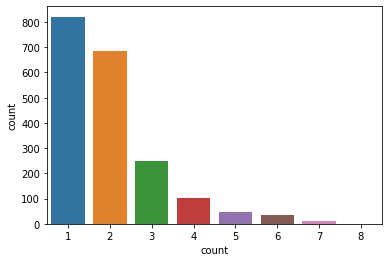

In [13]:
sns.countplot(cabin_unique_check['count'])

# this distribution is made from passengers group, exclude alone passengers.

In [14]:
# cabin split
cabin_check_split = [str(x).split('/') if x!='nan' else x for x in cabin_unique_check['list']]
cabin_check_deck = [x[0] if len(x)>1 else x[0] for x in cabin_check_split]
cabin_check_num = [int(x[1]) if len(x)>1 else -100 for x in cabin_check_split]
cabin_check_side = [x[2] if len(x)>1 else x[0] for x in cabin_check_split]

cabin_check_df = pd.DataFrame(zip(cabin_check_deck, cabin_check_num, cabin_check_side, cabin_unique_check['length'], cabin_unique_check['count'], cabin_unique_check['include_nan'])).rename(columns={0:'cabin_deck', 1:'cabin_num', 2:'cabin_side', 3:'length', 4:'count', 5:'include_nan'})

print(cabin_check_df)
print(Counter(cabin_check_df[cabin_check_df['cabin_deck']=='A']['cabin_num']))

     cabin_deck  cabin_num cabin_side  length  count  include_nan
0             A          0          S       1      2            0
1             F          2          S       2      1            0
2             G          0          S       2      1            0
3             B          1          P       1      3            0
4             G          0          P       2      1            0
...         ...        ...        ...     ...    ...          ...
1949          E        607          S       1      2            0
1950          G       1507          P       2      1            0
1951          F       1894          P       2      1            0
1952          A         97          P       1      3            0
1953          E        608          S       1      2            0

[1954 rows x 6 columns]
Counter({0: 2, 14: 2, 16: 2, 20: 2, 23: 2, 27: 2, 51: 2, 54: 2, 57: 2, 67: 2, 75: 2, 97: 2, 1: 1, 2: 1, 5: 1, 7: 1, 4: 1, 8: 1, 9: 1, 13: 1, 26: 1, 29: 1, 30: 1, 19: 1, 21: 1, 22: 1, 

In [15]:
train_data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'RoomService_log', 'FoodCourt_log',
       'ShoppingMall_log', 'Spa_log', 'VRDeck_log', 'ServiceSum',
       'RoomService_bool', 'FoodCourt_bool', 'ShoppingMall_bool', 'Spa_bool',
       'VRDeck_bool', 'num_services', 'services_bool', 'group_id', 'secondId',
       'member_num', 'group_bool', 'under13yrs'],
      dtype='object')

A
1 107 None


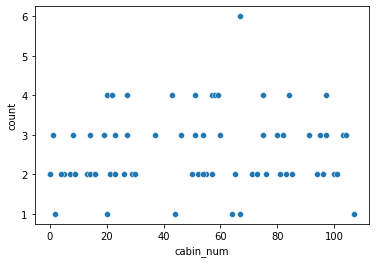

B
1 350 None


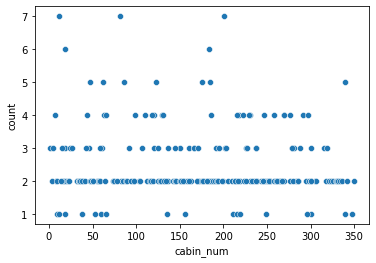

C
6 339 None


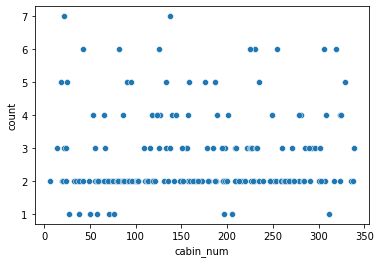

D
3 291 None


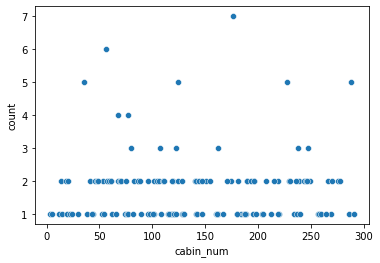

E
3 608 None


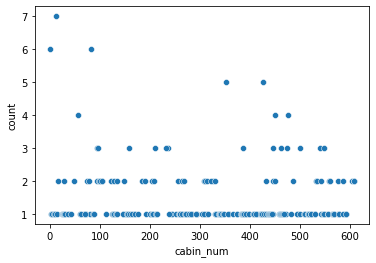

F
2 1894 None


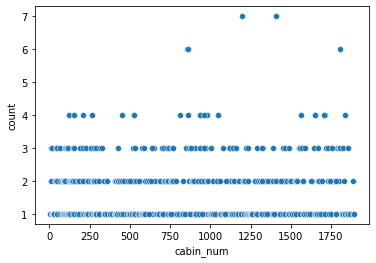

G
3 1507 None


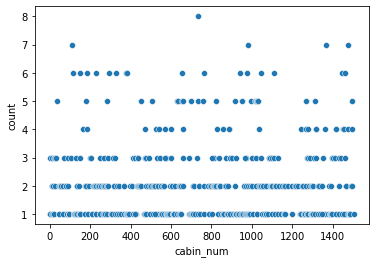

T
nan nan None


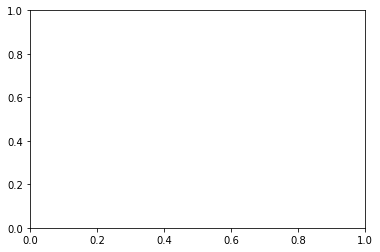

nan
nan nan None


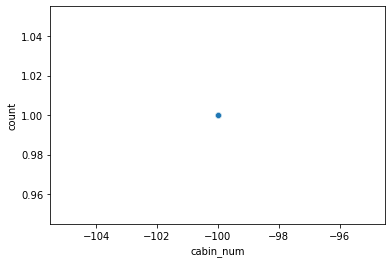

In [16]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']

#cabinnum_test = pd.DataFrame.from_dict(Counter(cabin_check_df[cabin_check_df['cabin_deck']=='F']['cabin_num']), orient = "index")
#print(cabinnum_test)

#sns.scatterplot(x=cabinnum_test.index, y=cabinnum_test[0])
for x in cabin_order_list:
    #cabinnum_test = pd.DataFrame.from_dict(Counter(cabin_check_df[cabin_check_df['cabin_deck']==x]['cabin_num']), orient = "index")
    print(cabin_check_df[(cabin_check_df['cabin_deck']==x) & (cabin_check_df['cabin_num']>0)]['cabin_num'].min(),
          cabin_check_df[(cabin_check_df['cabin_deck']==x) & (cabin_check_df['cabin_num']>0)]['cabin_num'].max(),
          print(x))
    sns.scatterplot(data = cabin_check_df[cabin_check_df['cabin_deck']==x], x='cabin_num', y='count')
    plt.show()

In [17]:
train_data[(train_data['group_id']==4498)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,ShoppingMall_bool,Spa_bool,VRDeck_bool,num_services,services_bool,group_id,secondId,member_num,group_bool,under13yrs
4221,4498_01,Earth,False,G/734/S,55 Cancri e,11.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,01,8,True,True
4222,4498_02,Earth,True,G/734/S,PSO J318.5-22,14.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,02,8,True,False
4223,4498_03,Earth,True,G/734/S,PSO J318.5-22,4.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,03,8,True,True
4224,4498_04,Earth,False,G/734/S,TRAPPIST-1e,11.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,04,8,True,True
4225,4498_05,Earth,True,G/734/S,TRAPPIST-1e,31.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,05,8,True,False
4226,4498_06,Earth,False,G/734/S,TRAPPIST-1e,15.0,False,0.0,893.0,0.0,...,False,False,False,1,True,4498,06,8,True,False
4227,4498_07,Earth,False,G/734/S,TRAPPIST-1e,39.0,False,0.0,2.0,0.0,...,False,True,True,3,True,4498,07,8,True,False
4228,4498_08,Earth,False,G/734/S,TRAPPIST-1e,7.0,False,0.0,0.0,0.0,...,False,False,False,0,False,4498,08,8,True,True


# Check blank data

In [18]:
train_data.isnull().sum()

PassengerId            0
HomePlanet           201
CryoSleep            217
Cabin                199
Destination          182
Age                  179
VIP                  203
RoomService          107
FoodCourt            106
ShoppingMall         103
Spa                  114
VRDeck               107
Name                 200
Transported            0
RoomService_log      181
FoodCourt_log        183
ShoppingMall_log     208
Spa_log              183
VRDeck_log           188
ServiceSum           518
RoomService_bool       0
FoodCourt_bool         0
ShoppingMall_bool      0
Spa_bool               0
VRDeck_bool            0
num_services           0
services_bool          0
group_id               0
secondId               0
member_num             0
group_bool             0
under13yrs           179
dtype: int64

In [19]:
train_data[train_data.isnull().sum(axis = 1)>0]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,ShoppingMall_bool,Spa_bool,VRDeck_bool,num_services,services_bool,group_id,secondId,member_num,group_bool,under13yrs
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,...,False,False,False,0,False,6,02,2,True,False
10,0008_02,Europa,True,B/1/P,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,...,False,False,False,0,False,8,02,3,True,False
15,0012_01,Earth,False,NaN,TRAPPIST-1e,31.0,False,32.0,0.0,876.0,...,True,False,False,2,True,12,01,1,False,False
16,0014_01,Mars,False,F/3/P,55 Cancri e,27.0,False,1286.0,122.0,NaN,...,False,False,False,2,True,14,01,1,False,False
23,0020_03,Earth,True,E/0/S,55 Cancri e,29.0,False,0.0,0.0,0.0,...,False,False,False,0,False,20,03,6,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,9250_01,Europa,False,E/597/P,TRAPPIST-1e,29.0,False,0.0,2972.0,NaN,...,False,True,True,3,True,9250,01,1,False,False
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,...,True,True,False,3,True,9257,01,1,False,False
8675,9259_01,Earth,NaN,F/1893/P,TRAPPIST-1e,44.0,False,1030.0,1015.0,0.0,...,False,True,False,3,True,9259,01,1,False,False
8684,9274_01,NaN,True,G/1508/P,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,...,False,False,False,0,False,9274,01,1,False,False


In [20]:
# distribution of number of missing data in each passengers
Counter(train_data[train_data.isnull().sum(axis = 1)>0].isnull().sum(axis = 1))

# Passengers who have one missing data is the most.
# So if you want to impute the missing variable, you can use other informations!

Counter({1: 1274, 3: 469, 2: 264, 4: 53, 5: 25, 6: 2})

In [21]:
Counter(test_data[test_data.isnull().sum(axis = 1)>0].isnull().sum(axis = 1))

Counter({1: 1274, 3: 469, 2: 264, 4: 53, 5: 25, 6: 2})

## variables
- boolian variable : VIP, CryoSleep, Transported(= target variable)
- Category variable : PassengerId, HomePlanet, Cabin, Destination, Name(or it is string variable)
- Numerical variable : Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

## check
- PassengerId and Cabin will be splitted into some pieces and stored into new variables.
- Services will be log transformed.
- Name cannot be imputed, but can create new variable name_isnull.

## strategy
- I already know that the variables for luxuary services and Age are very important for LGBM. These variables should be imputed.

# data imputation

## data prep for imputation

In [22]:
# cabin
cabin_split = [str(x).split('/') if x!='nan' else x for x in train_data['Cabin']]
cabin_deck = [x[0] if len(x)>1 else x[0] for x in cabin_split]
cabin_num = [round(float(x[1])/10) if len(x)>1 else math.nan for x in cabin_split]
cabin_side = [x[2] if len(x)>1 else x[0] for x in cabin_split]

cabin_df = pd.DataFrame(zip(cabin_deck, cabin_num, cabin_side, train_data['Age'])).rename(columns={0:'cabin_deck', 1:'cabin_num', 2:'cabin_side', 3:'Age'})

In [23]:
train_data = pd.concat([train_data, cabin_df], axis=1)
train_data

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,services_bool,group_id,secondId,member_num,group_bool,under13yrs,cabin_deck,cabin_num,cabin_side,Age
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,False,1,01,1,False,False,B,0.0,P,39.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,True,2,01,1,False,False,F,0.0,S,24.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,True,3,01,2,True,False,A,0.0,S,58.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,True,3,02,2,True,False,A,0.0,S,33.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,True,4,01,1,False,False,F,0.0,S,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,...,True,9276,01,1,False,False,A,10.0,P,41.0
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,...,False,9278,01,1,False,False,G,150.0,S,18.0
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,...,True,9279,01,1,False,False,G,150.0,S,26.0
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,...,True,9280,01,2,True,False,E,61.0,S,32.0


In [24]:
train_data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'RoomService_log', 'FoodCourt_log',
       'ShoppingMall_log', 'Spa_log', 'VRDeck_log', 'ServiceSum',
       'RoomService_bool', 'FoodCourt_bool', 'ShoppingMall_bool', 'Spa_bool',
       'VRDeck_bool', 'num_services', 'services_bool', 'group_id', 'secondId',
       'member_num', 'group_bool', 'under13yrs', 'cabin_deck', 'cabin_num',
       'cabin_side', 'Age'],
      dtype='object')

## CryoSleep

Earth


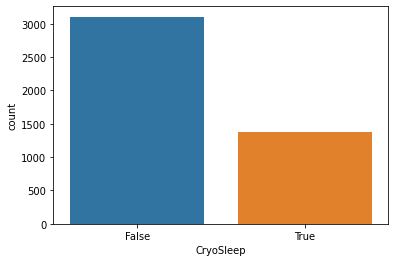

Mars


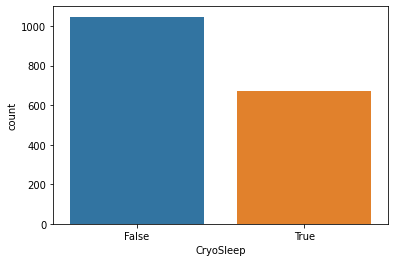

Europa


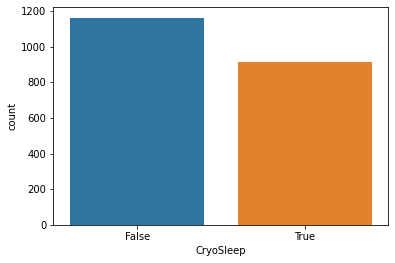

TRAPPIST-1e


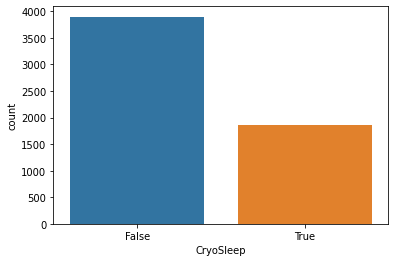

PSO J318.5-22


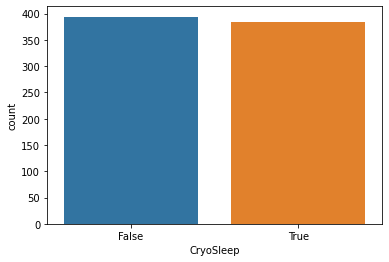

55 Cancri e


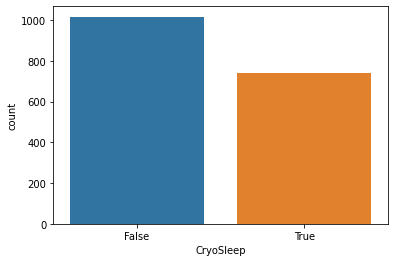

A


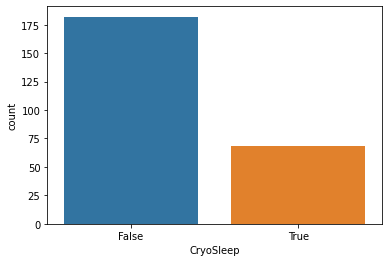

B


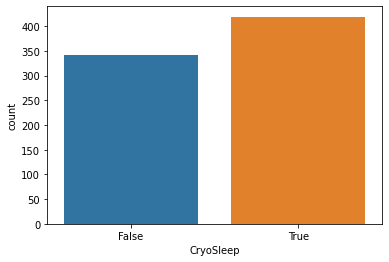

C


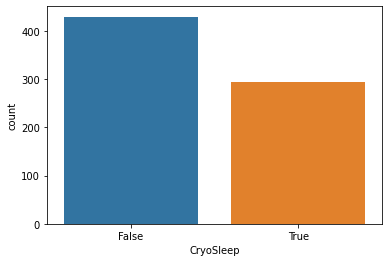

D


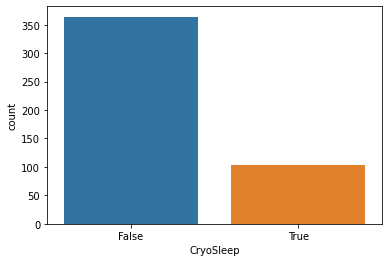

E


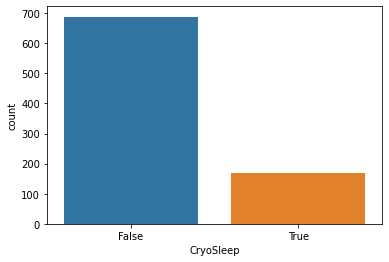

F


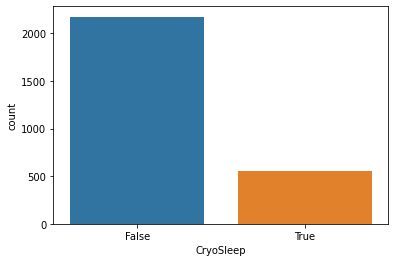

G


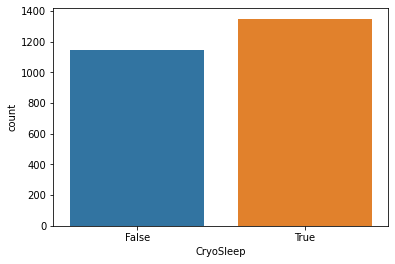

T


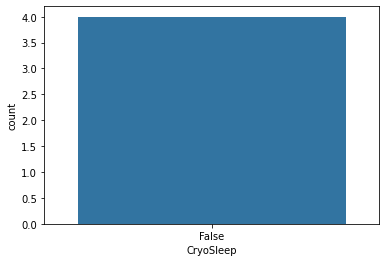

nan


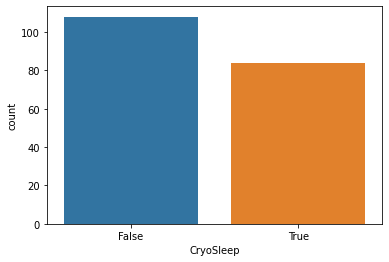

In [25]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']
destination_order_list = ['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e']
planet_order_list = ['Earth', 'Mars', 'Europa']

for p in planet_order_list:
    print(p)
    sns.countplot(train_data[train_data['HomePlanet']==p]['CryoSleep'])
    plt.show()
    
for d in destination_order_list:
    print(d)
    sns.countplot(train_data[train_data['Destination']==d]['CryoSleep'])
    plt.show()
    
for c in cabin_order_list:
    print(c)
    sns.countplot(train_data[train_data['cabin_deck']==c]['CryoSleep'])
    plt.show()

In [26]:
train_data_cryosleep_dummy = pd.get_dummies(train_data['CryoSleep'])
train_data_cryosleep_dummy = pd.concat([train_data[['HomePlanet', 'Destination','cabin_deck','group_bool', 'services_bool']], train_data_cryosleep_dummy], axis=1)
train_data_cryosleep_mean = pd.DataFrame(train_data_cryosleep_dummy.groupby(['HomePlanet', 'Destination','cabin_deck','group_bool', 'services_bool'], dropna=False).mean())
train_data_cryosleep_argmax = train_data_cryosleep_mean.apply(np.argmax, axis=1)
print(train_data_cryosleep_mean)
print(train_data_cryosleep_argmax)

                                                               False  True
HomePlanet Destination cabin_deck group_bool services_bool                
Earth      55 Cancri e E          False      True           1.000000  0.00
                                  True       False          0.250000  0.75
                                             True           1.000000  0.00
                       F          False      False          0.500000  0.50
                                             True           0.980198  0.00
...                                                              ...   ...
NaN        TRAPPIST-1e nan        False      True           1.000000  0.00
                                  True       False          0.000000  1.00
           NaN         F          False      True           1.000000  0.00
                       G          False      True           1.000000  0.00
                                  True       False          1.000000  0.00

[241 rows x 2 columns]
H

Counter({False: 5067, True: 3626})
Counter({False: 5439, True: 3037, nan: 217})
Counter({False: 4947, True: 3529})
[False, False, False, False, False, False, False, True, False, True]
[True, False, False, False, False, False, False, True, False, True]
[[4936  503]
 [  11 3026]]


Counter({True: 3529, False: 4947})

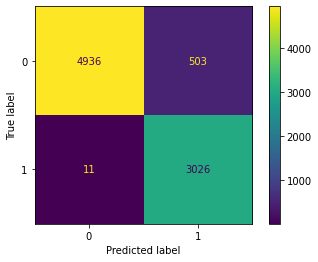

In [27]:
# imputation test for CryoSleep
cryosleep_imputed = np.repeat(False, len(train_data))
#print(homeplanet_imputed, len(homeplanet_imputed))
cryosleep_order_list = [False, True]

for idx, i in enumerate(train_data_cryosleep_mean.index):
    #train_data_homeplanet_argmax[]
    if pd.isna(i[0]) & pd.notna(i[1]):
        index_list = train_data.index[(pd.isna(train_data['HomePlanet'])) & \
                                      (train_data['Destination']==i[1]) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    elif pd.notna(i[0]) & pd.isna(i[1]):
        index_list = train_data.index[(train_data['HomePlanet']==i[0]) & \
                                      (pd.isna(train_data['Destination'])) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    elif pd.isna(i[0]) & pd.isna(i[1]):
        index_list = train_data.index[(pd.isna(train_data['HomePlanet'])) & \
                                      (pd.isna(train_data['Destination'])) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    else:
        index_list = train_data.index[(train_data['HomePlanet']==i[0]) & \
                                      (train_data['Destination']==i[1]) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    impute_value = train_data_cryosleep_argmax[idx]
    #print(impute_value, planet_order_list[impute_value])
    
    cryosleep_imputed[index_list] = cryosleep_order_list[impute_value]
    #print(train_data_homeplanet_argmax[idx])
    #print(idx, i[0], i[1])

#print(np.where(homeplanet_imputed=='xxxxxxxx'))
#print(train_data.iloc[47])
#homeplanet_imputed.tolist()

print(Counter(cryosleep_imputed))
print(Counter(list(train_data['CryoSleep'])))
print(Counter(cryosleep_imputed[pd.notna(train_data['CryoSleep'])].tolist()))

print(list(train_data['CryoSleep'])[:10])
print(cryosleep_imputed.tolist()[:10])

cm = confusion_matrix(list(train_data[pd.notna(train_data['CryoSleep'])]['CryoSleep'].astype(int)),
                      cryosleep_imputed[pd.notna(train_data['CryoSleep'])].astype(int).tolist(),
                      labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0, 1])
disp.plot()

Counter(cryosleep_imputed[pd.notna(train_data['CryoSleep'])])

In [28]:
cryosleep_blank_index = train_data.index[pd.isna(train_data['CryoSleep'])]
cryosleep_series = train_data['CryoSleep']
cryosleep_series[cryosleep_blank_index] = cryosleep_imputed[cryosleep_blank_index]
print(pd.isna(cryosleep_series).sum())
print(pd.isna(cryosleep_series).sum())

train_data['imputed_CryoSleep'] = cryosleep_series
print(train_data)

0
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  ...

## under 13 years old flag

In [29]:
train_data_under13yrs_dummy = pd.get_dummies(train_data['under13yrs'])
train_data_under13yrs_dummy = pd.concat([train_data[['HomePlanet', 'Destination','cabin_deck','group_bool', 'services_bool', 'imputed_CryoSleep']], train_data_under13yrs_dummy], axis=1)
train_data_under13yrs_mean = pd.DataFrame(train_data_under13yrs_dummy.groupby(['HomePlanet', 'Destination','cabin_deck','group_bool', 'services_bool', 'imputed_CryoSleep'], dropna=False).mean())
train_data_under13yrs_argmax = train_data_under13yrs_mean.apply(np.argmax, axis=1)
print(train_data_under13yrs_mean)
print(train_data_under13yrs_argmax)

                                                                                 False  \
HomePlanet Destination cabin_deck group_bool services_bool imputed_CryoSleep             
Earth      55 Cancri e E          False      True          False              1.000000   
                                  True       False         False              0.000000   
                                                           True               0.666667   
                                             True          False              1.000000   
                       F          False      False         False              1.000000   
...                                                                                ...   
NaN        TRAPPIST-1e nan        False      True          False              1.000000   
                                  True       False         True               0.500000   
           NaN         F          False      True          False              1.000000   
          

Counter({False: 7231, True: 1462})
Counter({False: 7708, True: 806, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan:

Counter({False: 7086, True: 1428})

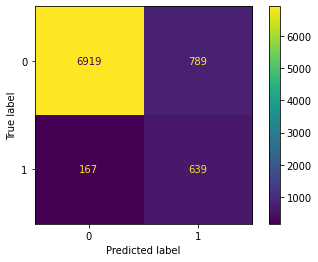

In [30]:
# imputation test for under13yrs
under13yrs_imputed = np.repeat(False, len(train_data))
#print(homeplanet_imputed, len(homeplanet_imputed))
under13yrs_order_list = [False, True]

for idx, i in enumerate(train_data_under13yrs_mean.index):
    #train_data_homeplanet_argmax[]
    if pd.isna(i[0]) & pd.notna(i[1]):
        index_list = train_data.index[(pd.isna(train_data['HomePlanet'])) & \
                                      (train_data['Destination']==i[1]) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4]) & \
                                      (train_data['imputed_CryoSleep']==i[5])].to_list()
    elif pd.notna(i[0]) & pd.isna(i[1]):
        index_list = train_data.index[(train_data['HomePlanet']==i[0]) & \
                                      (pd.isna(train_data['Destination'])) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4]) & \
                                      (train_data['imputed_CryoSleep']==i[5])].to_list()
    elif pd.isna(i[0]) & pd.isna(i[1]):
        index_list = train_data.index[(pd.isna(train_data['HomePlanet'])) & \
                                      (pd.isna(train_data['Destination'])) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['services_bool']==i[4]) & \
                                      (train_data['imputed_CryoSleep']==i[5])].to_list()
    else:
        index_list = train_data.index[(train_data['HomePlanet']==i[0]) & \
                                      (train_data['Destination']==i[1]) & \
                                      (train_data['cabin_deck']==i[2]) & \
                                      (train_data['services_bool']==i[4]) & \
                                      (train_data['imputed_CryoSleep']==i[5])].to_list()
    impute_value = train_data_under13yrs_argmax[idx]
    #print(impute_value, planet_order_list[impute_value])
    
    under13yrs_imputed[index_list] = under13yrs_order_list[impute_value]

print(Counter(under13yrs_imputed))
print(Counter(list(train_data['under13yrs'])))
print(Counter(under13yrs_imputed[pd.notna(train_data['under13yrs'])].tolist()))

print(list(train_data['under13yrs'])[:10])
print(under13yrs_imputed.tolist()[:10])

cm = confusion_matrix(list(train_data[pd.notna(train_data['under13yrs'])]['under13yrs'].astype(int)),
                      under13yrs_imputed[pd.notna(train_data['under13yrs'])].astype(int).tolist(),
                      labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0, 1])
disp.plot()

Counter(under13yrs_imputed[pd.notna(train_data['under13yrs'])])

In [31]:
under13yrs_blank_index = train_data.index[pd.isna(train_data['under13yrs'])]
under13yrs_series = train_data['under13yrs']
under13yrs_series[under13yrs_blank_index] = under13yrs_imputed[under13yrs_blank_index]
print(pd.isna(under13yrs_series).sum())
print(pd.isna(under13yrs_series).sum())

train_data['imputed_under13yrs'] = under13yrs_series
print(train_data)
print(Counter(train_data['imputed_under13yrs']))

0
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  ...

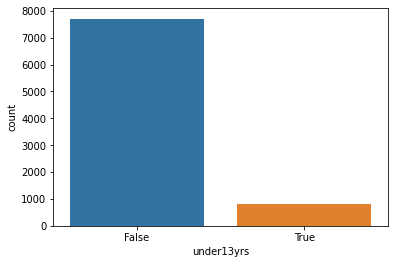

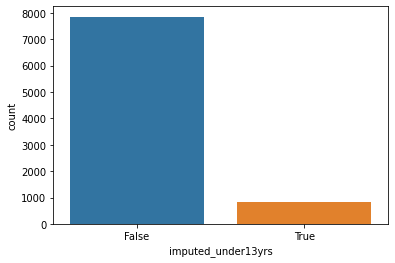

In [32]:
sns.countplot(train_data['under13yrs'])
plt.show()
sns.countplot(train_data['imputed_under13yrs'])
plt.show()

## HomePlanet
- cabin_deck and homeplanet are related

In [33]:
# check : Are passengers in same group from same homeplanet?

def PlanetListCheck(g):
    check_list = g['HomePlanet'].unique()
    check_len = len(check_list[pd.notna(check_list)])
    
    if check_len==0:
        print(g['group_id'])
        print(check_list)
        print(pd.notna(check_list))
        print(check_len)
    return check_len

homeplanet_group_check = train_data[train_data['group_bool']==True][['HomePlanet', 'group_id']]
print(Counter(homeplanet_group_check.groupby('group_id').apply(PlanetListCheck)))
print(train_data[train_data['group_id']==7336])

# result : passengers in same group are from same homeplanet!
# Homeplanet of Passengers in group_id 7336 are NaN. These cannot be imputed by deterministic way.

6917    7336
6918    7336
Name: group_id, dtype: int64
[nan]
[False]
0
Counter({1: 1411, 0: 1})
     PassengerId HomePlanet CryoSleep     Cabin  Destination   Age    VIP  \
6917     7336_01        NaN     False  F/1411/S  TRAPPIST-1e  30.0  False   
6918     7336_02        NaN     False  F/1411/S  TRAPPIST-1e  26.0  False   

      RoomService  FoodCourt  ShoppingMall  ...  secondId  member_num  \
6917          2.0        0.0           5.0  ...        01           2   
6918          0.0        0.0         902.0  ...        02           2   

     group_bool  under13yrs  cabin_deck  cabin_num  cabin_side   Age  \
6917       True       False           F      141.0           S  30.0   
6918       True       False           F      141.0           S  26.0   

      imputed_CryoSleep  imputed_under13yrs  
6917              False               False  
6918              False               False  

[2 rows x 38 columns]


In [34]:
# create homeplanet impute table by group_id
def PlanetImputeTable(g):
    check_list = g['HomePlanet'].unique()
    group_planet = check_list[pd.notna(check_list)]
    if len(group_planet)==0:
        return math.nan
    else:
        return group_planet[0]

homeplanet_group_check = train_data[train_data['group_bool']==True][['HomePlanet', 'group_id']]
homeplanet_impute_table_groupid = homeplanet_group_check.groupby('group_id').apply(PlanetImputeTable)
homeplanet_impute_table_groupid = homeplanet_impute_table_groupid[pd.notna(homeplanet_impute_table_groupid)]
homeplanet_impute_table_groupid

group_id
3       Europa
6        Earth
8       Europa
17       Earth
20       Earth
         ...  
9252    Europa
9267    Europa
9272     Earth
9275    Europa
9280    Europa
Length: 1411, dtype: object

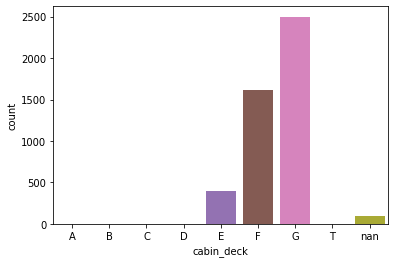

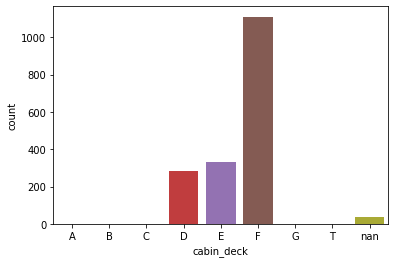

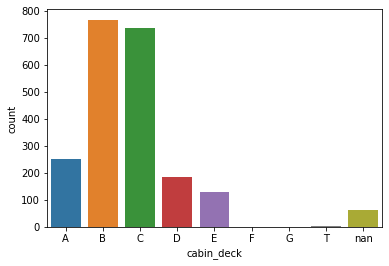

In [35]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']
planet_order_list = ['Earth', 'Mars', 'Europa']

for p in planet_order_list:
    sns.countplot(cabin_df[train_data['HomePlanet']==p]['cabin_deck'], order=cabin_order_list)
    plt.show()

TRAPPIST-1e


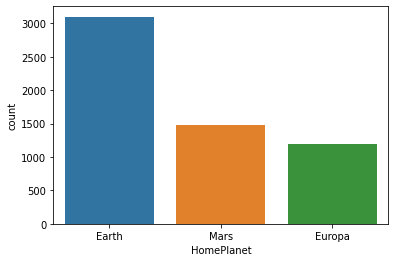

PSO J318.5-22


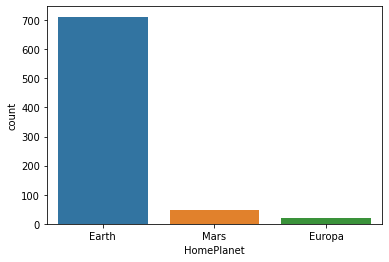

55 Cancri e


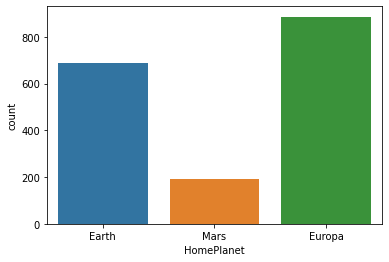

nan


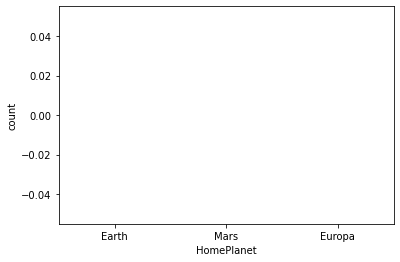

In [36]:
destination_order_list = ['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', 'nan']
planet_order_list = ['Earth', 'Mars', 'Europa']

for d in destination_order_list:
    print(d)
    sns.countplot(train_data[train_data['Destination']==d]['HomePlanet'], order=planet_order_list)
    plt.show()

False


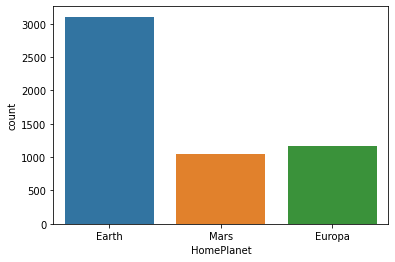

True


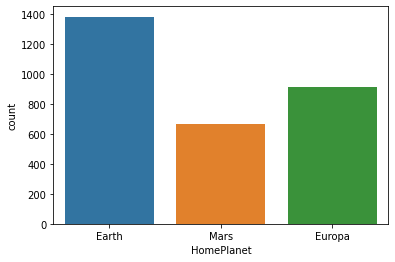

nan


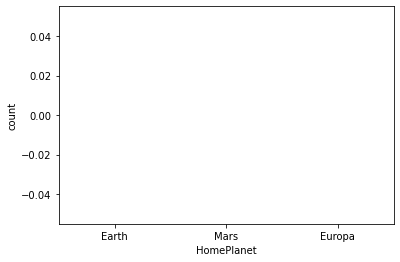

False


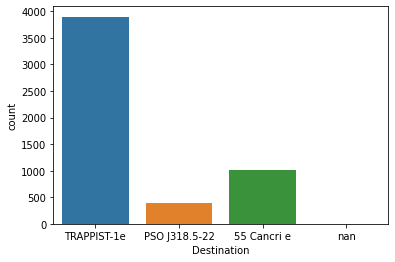

True


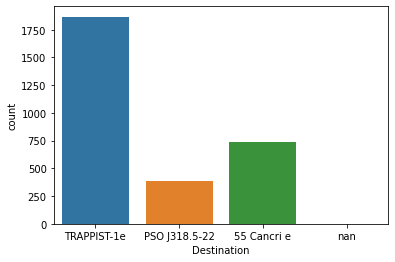

nan


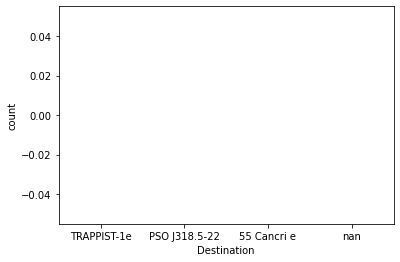

In [37]:
cryosleep_list = [False, True, 'nan']
destination_order_list = ['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', 'nan']
planet_order_list = ['Earth', 'Mars', 'Europa']

for c in cryosleep_list:
    print(c)
    sns.countplot(train_data[train_data['CryoSleep']==c]['HomePlanet'], order=planet_order_list)
    plt.show()
    
for c in cryosleep_list:
    print(c)
    sns.countplot(train_data[train_data['CryoSleep']==c]['Destination'], order=destination_order_list)
    plt.show()

In [38]:
homeplanet_imputation_table = pd.DataFrame(train_data.groupby(['Destination','cabin_deck','group_bool'])['HomePlanet'].value_counts())
#print(homeplanet_imputation_table[:28])
#print(homeplanet_imputation_table[28:49])
#print(homeplanet_imputation_table[49:78])

train_data_homeplanet_dummy = pd.get_dummies(train_data['HomePlanet'])
train_data_homeplanet_dummy = pd.concat([train_data[['Destination','cabin_deck','group_bool', 'services_bool']], train_data_homeplanet_dummy], axis=1)
train_data_homeplanet_mean = pd.DataFrame(train_data_homeplanet_dummy.groupby(['Destination','cabin_deck','group_bool', 'services_bool'], dropna=False).mean())
train_data_homeplanet_argmax = train_data_homeplanet_mean.apply(np.argmax, axis=1)
print(train_data_homeplanet_mean)
print(train_data_homeplanet_argmax)

                                                 Earth    Europa  Mars
Destination cabin_deck group_bool services_bool                       
55 Cancri e A          False      False            0.0  0.900000   0.0
                                  True             0.0  1.000000   0.0
                       True       False            0.0  1.000000   0.0
                                  True             0.0  0.973684   0.0
            B          False      False            0.0  0.985507   0.0
...                                                ...       ...   ...
NaN         G          True       True             1.0  0.000000   0.0
            nan        False      False            0.0  0.000000   1.0
                                  True             0.0  0.000000   1.0
                       True       False            1.0  0.000000   0.0
                                  True             1.0  0.000000   0.0

[121 rows x 3 columns]
Destination  cabin_deck  group_bool  services_bool
55

array(['Mars', 'Europa', 'Europa', 'Earth', 'Europa', 'Earth', 'Earth',
       'Earth', 'Earth', 'Europa', 'Earth', 'Earth', 'Mars', 'Europa',
       'Mars', 'Europa', 'Earth', 'Earth', 'Earth', 'Earth', 'Mars',
       'Europa', 'Earth', 'Earth', 'Earth', 'Mars', 'Europa', 'Europa',
       'Europa', 'Earth', 'Earth', 'Earth', 'Earth', 'Europa', 'Mars',
       'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth',
       'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Europa', 'Mars',
       'Earth', 'Earth', 'Earth', 'Europa', 'Earth', 'Mars', 'Earth',
       'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth',
       'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth',
       'Earth', 'Mars', 'Earth', 'Europa', 'Earth', 'Mars', 'Earth',
       'Earth', 'Mars', 'Earth', 'Earth', 'Earth', 'Earth', 'Europa',
       'Earth', 'Earth', 'Earth', 'Earth', 'Mars', 'Europa', 'Earth',
       'Europa', 'Earth', 'Earth', 'Europa', 'Earth', 'Mars', 'Earth',
       'Earth',

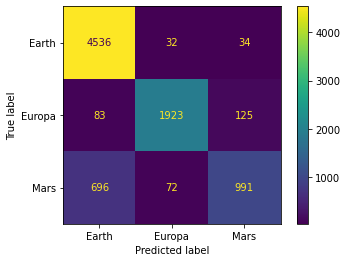

In [39]:
# imputation test for HomePlanet
homeplanet_imputed = np.repeat('xxxxxxxx', len(train_data))
#print(homeplanet_imputed, len(homeplanet_imputed))
planet_order_list = ['Earth', 'Europa', 'Mars']

for idx, i in enumerate(train_data_homeplanet_mean.index):
    #train_data_homeplanet_argmax[]
    if pd.isna(i[0]):
        index_list = train_data.index[(pd.isna(train_data['Destination'])) & \
                                      (train_data['cabin_deck']==i[1]) & \
                                      (train_data['group_bool']==i[2]) & \
                                      (train_data['services_bool']==i[3])].to_list()
    else:
        index_list = train_data.index[(train_data['Destination']==i[0]) & \
                                      (train_data['cabin_deck']==i[1]) & \
                                      (train_data['group_bool']==i[2]) & \
                                      (train_data['services_bool']==i[3])].to_list()
    impute_value = train_data_homeplanet_argmax[idx]
    #print(impute_value, planet_order_list[impute_value])
    
    homeplanet_imputed[index_list] = planet_order_list[impute_value]
    #print(train_data_homeplanet_argmax[idx])
    #print(idx, i[0], i[1])

#print(np.where(homeplanet_imputed=='xxxxxxxx'))
#print(train_data.iloc[47])
#homeplanet_imputed.tolist()

cm = confusion_matrix(list(train_data['HomePlanet']), homeplanet_imputed.tolist(),
                      labels=['Earth', 'Europa', 'Mars'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Earth', 'Europa', 'Mars'])
disp.plot()

homeplanet_imputed[pd.isna(train_data['HomePlanet'])]



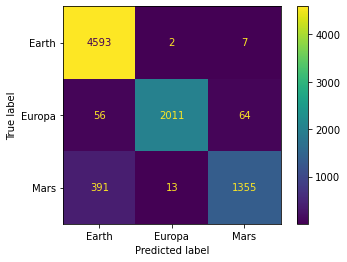

In [40]:
# impute by group_id
for i in homeplanet_impute_table_groupid.index:
    homeplanet_imputed[train_data['group_id']==i] = homeplanet_impute_table_groupid[i]

cm = confusion_matrix(list(train_data['HomePlanet']), homeplanet_imputed.tolist(),
                      labels=['Earth', 'Europa', 'Mars'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Earth', 'Europa', 'Mars'])
disp.plot()

In [41]:
homeplanet_blank_index = train_data.index[pd.isna(train_data['HomePlanet'])]
homeplanet_series = train_data['HomePlanet']
print(pd.isna(homeplanet_series).sum())
homeplanet_series[homeplanet_blank_index] = homeplanet_imputed[homeplanet_blank_index]
print(pd.isna(homeplanet_series).sum())

train_data['imputed_HomePlanet'] = homeplanet_series
print(train_data)

201
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  .

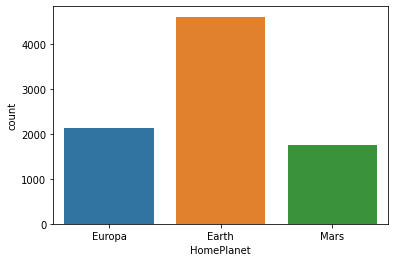

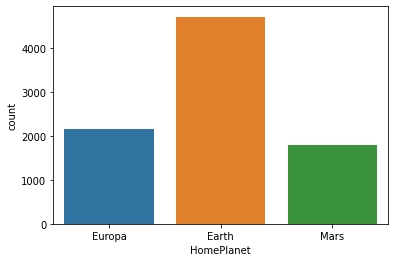

Counter({'Earth': 4602, 'Europa': 2131, 'Mars': 1759, nan: 201})
Counter({'Earth': 4724, 'Europa': 2172, 'Mars': 1797})


In [42]:
sns.countplot(train_data['HomePlanet'])
plt.show()
sns.countplot(homeplanet_series)
plt.show()

print(Counter(train_data['HomePlanet']))
print(Counter(homeplanet_series))

## Destination imputation

In [43]:
# check : Are passengers in same group to same destination?

def DestinationListCheck(g):
    check_list = g['Destination'].unique()
    check_len = len(check_list[pd.notna(check_list)])
    
    if check_len==0:
        print(g['group_id'])
        print(check_list)
        print(pd.notna(check_list))
        print(check_len)
    return check_len

destination_group_check = train_data[train_data['group_bool']==True][['Destination', 'group_id']]
print(Counter(destination_group_check.groupby('group_id').apply(DestinationListCheck)))

# result : passengers in same group are NOT to same destination! This imputation method cannot be applied.

Counter({1: 695, 2: 668, 3: 49})


In [44]:
Counter(train_data['Destination'])

Counter({'TRAPPIST-1e': 5915,
         'PSO J318.5-22': 796,
         '55 Cancri e': 1800,
         nan: 182})

In [45]:
count_destination = pd.DataFrame.from_dict(Counter(train_data['Destination']), orient='index', columns=['count'])
count_destination = count_destination[count_destination.index.notna()]
desitination_weight = (1/np.array(count_destination['count']))/((1/np.array(count_destination['count'])).sum())

desitination_weight = np.array([desitination_weight[2]*4.5,
                                desitination_weight[1]*3,
                                desitination_weight[0]*10])

#desitination_weight = np.array([desitination_weight[2],
#                                desitination_weight[1],
#                                desitination_weight[0]])

desitination_weight

array([1.26205345, 1.90259314, 0.85345964])

In [46]:
train_data_destination_dummy = pd.get_dummies(train_data['Destination'])
train_data_destination_dummy = pd.concat([train_data[['imputed_HomePlanet', 'cabin_deck','imputed_CryoSleep','group_bool', 'services_bool']], train_data_destination_dummy], axis=1)
print(train_data_destination_dummy)
train_data_destination_mean = pd.DataFrame(train_data_destination_dummy.groupby(['imputed_HomePlanet', 'cabin_deck','imputed_CryoSleep','group_bool', 'services_bool'], dropna=False).mean())

def StandardizedMaxExtact(row):
    #print(np.array(row))
    #print(np.array(row) * desitination_weight)
    return np.argmax(np.array(row) * desitination_weight)
    
train_data_destination_argmax = train_data_destination_mean.apply(StandardizedMaxExtact, axis=1)

#train_data_destination_argmax = train_data_destination_mean.apply(np.argmax, axis=1)
#print(train_data_destination_mean)
#print(train_data_destination_argmax)

     imputed_HomePlanet cabin_deck imputed_CryoSleep  group_bool  \
0                Europa          B             False       False   
1                 Earth          F             False       False   
2                Europa          A             False        True   
3                Europa          A             False        True   
4                 Earth          F             False       False   
...                 ...        ...               ...         ...   
8688             Europa          A             False       False   
8689              Earth          G              True       False   
8690              Earth          G             False       False   
8691             Europa          E             False        True   
8692             Europa          E             False        True   

      services_bool  55 Cancri e  PSO J318.5-22  TRAPPIST-1e  
0             False            0              0            1  
1              True            0              0          

0.6501783043828367
0.634220625704574


array(['TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'PSO J318.5-22', '55 Cancri e', '55 Cancri e', '55 Cancri e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', '55 Cancri e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'PSO J318.5-22', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', '55 Cancri e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       '55 Cancri e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', '55 Cancri e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'PSO J318.5-22',
       'TRAPPIST-1e', 'TRAPPIST-1e', 'TRAPPIST-1e', 'TRA

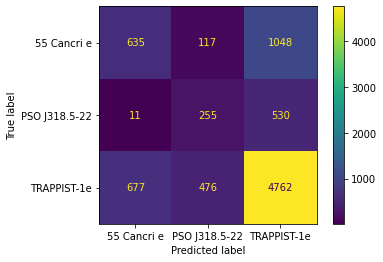

In [47]:
# imputation test for Destination
destination_imputed = np.repeat('xxxxxxxxxxxxx', len(train_data))
#print(homeplanet_imputed, len(homeplanet_imputed))
destination_order_list = ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']

for idx, i in enumerate(train_data_destination_mean.index):
    #train_data_homeplanet_argmax[]
    if pd.isna(i[0]):
        index_list = train_data.index[(pd.isna(train_data['imputed_HomePlanet'])) & \
                                      (train_data['cabin_deck']==i[1]) & \
                                      (train_data['imputed_CryoSleep']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    else:
        index_list = train_data.index[(train_data['imputed_HomePlanet']==i[0]) & \
                                      (train_data['cabin_deck']==i[1]) & \
                                      (train_data['imputed_CryoSleep']==i[2]) & \
                                      (train_data['group_bool']==i[3]) & \
                                      (train_data['services_bool']==i[4])].to_list()
    impute_value = train_data_destination_argmax[idx]
    #print(impute_value, planet_order_list[impute_value])
    
    destination_imputed[index_list] = destination_order_list[impute_value]
    #print(train_data_homeplanet_argmax[idx])
    #print(idx, i[0], i[1])

#print(np.where(homeplanet_imputed=='xxxxxxxx'))
#print(train_data.iloc[47])
#homeplanet_imputed.tolist()
#print(Counter(train_data['Destination']))
#print(Counter(destination_imputed.tolist()))

cm = confusion_matrix(list(train_data['Destination']), destination_imputed.tolist(),
                      labels=['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e'])
disp.plot()
print(accuracy_score(list(train_data['Destination']), 
               destination_imputed.tolist()))
print(f1_score(list(train_data['Destination']), 
               destination_imputed.tolist(),
               average = 'weighted'))

destination_imputed[pd.isna(train_data['Destination'])]

# this imputation value is not so good, but distination is not so important.

In [48]:
destination_blank_index = train_data.index[pd.isna(train_data['Destination'])]
destination_series = train_data['Destination']
print(pd.isna(destination_series).sum())
destination_series[destination_blank_index] = destination_imputed[destination_blank_index]
print(pd.isna(destination_series).sum())

train_data['imputed_Destination'] = destination_series
print(train_data)

182
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  .

## Cabin deck imputation

In [49]:
train_data_cabindeck_dummy = pd.get_dummies(train_data['cabin_deck'])
train_data_cabindeck_dummy = pd.concat([train_data[['imputed_HomePlanet', 'imputed_CryoSleep','group_bool', 'services_bool', 'imputed_Destination']], train_data_cabindeck_dummy], axis=1)
print(train_data_cabindeck_dummy)
train_data_cabindeck_mean = pd.DataFrame(train_data_cabindeck_dummy.groupby(['imputed_HomePlanet', 'imputed_CryoSleep','group_bool', 'services_bool', 'imputed_Destination'], dropna=False).mean())

train_data_cabindeck_argmax = train_data_cabindeck_mean.apply(np.argmax, axis=1)
print(train_data_cabindeck_mean)
print(train_data_cabindeck_argmax)

     imputed_HomePlanet imputed_CryoSleep  group_bool  services_bool  \
0                Europa             False       False          False   
1                 Earth             False       False           True   
2                Europa             False        True           True   
3                Europa             False        True           True   
4                 Earth             False       False           True   
...                 ...               ...         ...            ...   
8688             Europa             False       False           True   
8689              Earth              True       False          False   
8690              Earth             False       False           True   
8691             Europa             False        True           True   
8692             Europa             False        True           True   

     imputed_Destination  A  B  C  D  E  F  G  T  nan  
0            TRAPPIST-1e  0  1  0  0  0  0  0  0    0  
1            TRAPPIST-1

0.6185436558150236
0.5608578959478162


array([], dtype='<U13')

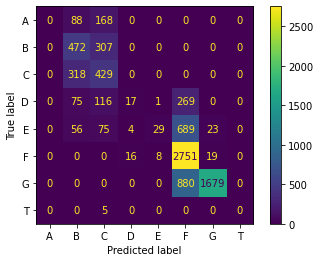

In [50]:
# imputation test for Cabin_deck
cabindeck_imputed = np.repeat('x', len(train_data))
cabindeck_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']

for idx, i in enumerate(train_data_cabindeck_mean.index):
    if pd.isna(i[0]):
        index_list = train_data.index[(pd.isna(train_data['imputed_HomePlanet'])) & \
                                      (train_data['imputed_CryoSleep']==i[1]) & \
                                      (train_data['group_bool']==i[2]) & \
                                      (train_data['services_bool']==i[3]) & \
                                      (train_data['imputed_Destination']==i[4])].to_list()
    else:
        index_list = train_data.index[(train_data['imputed_HomePlanet']==i[0]) & \
                                      (train_data['imputed_CryoSleep']==i[1]) & \
                                      (train_data['group_bool']==i[2]) & \
                                      (train_data['services_bool']==i[3]) & \
                                      (train_data['imputed_Destination']==i[4])].to_list()
    impute_value = train_data_cabindeck_argmax[idx]
    
    cabindeck_imputed[index_list] = cabindeck_order_list[impute_value]
    #print(train_data_homeplanet_argmax[idx])
    #print(idx, i[0], i[1])

#print(np.where(homeplanet_imputed=='xxxxxxxx'))
#print(train_data.iloc[47])
#homeplanet_imputed.tolist()
#print(Counter(train_data['Destination']))
#print(Counter(destination_imputed.tolist()))

cm = confusion_matrix(list(train_data['cabin_deck']), cabindeck_imputed.tolist(),
                      labels=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])
disp.plot()
print(accuracy_score(list(train_data['cabin_deck']), 
               cabindeck_imputed.tolist()))
print(f1_score(list(train_data['cabin_deck']), 
               cabindeck_imputed.tolist(),
               average = 'weighted'))

destination_imputed[pd.isna(train_data['cabin_deck'])]

In [51]:
cabindeck_blank_index = train_data.index[pd.isna(train_data['Cabin'])]
cabindeck_series = train_data['cabin_deck']
print(pd.isna(train_data['Cabin']).sum())
cabindeck_series[cabindeck_blank_index] = cabindeck_imputed[cabindeck_blank_index]
print(pd.isna(cabindeck_series).sum())

train_data['imputed_cabindeck'] = cabindeck_series
print(train_data)

199
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  .

## Cabin number imputation

In [52]:
Counter(train_data['imputed_cabindeck'])

Counter({'B': 813,
         'F': 2880,
         'A': 256,
         'G': 2608,
         'E': 876,
         'D': 479,
         'C': 776,
         'T': 5})

In [53]:
train_data_cabinnum = train_data[['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'group_bool', 'services_bool', 'cabin_num']]
print(train_data_cabinnum)
train_data_cabinnum_median = pd.DataFrame(train_data_cabinnum.groupby(['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'group_bool', 'services_bool']).median())

print(train_data_cabinnum_median)

     imputed_HomePlanet imputed_CryoSleep imputed_Destination  \
0                Europa             False         TRAPPIST-1e   
1                 Earth             False         TRAPPIST-1e   
2                Europa             False         TRAPPIST-1e   
3                Europa             False         TRAPPIST-1e   
4                 Earth             False         TRAPPIST-1e   
...                 ...               ...                 ...   
8688             Europa             False         55 Cancri e   
8689              Earth              True       PSO J318.5-22   
8690              Earth             False         TRAPPIST-1e   
8691             Europa             False         55 Cancri e   
8692             Europa             False         TRAPPIST-1e   

     imputed_cabindeck  group_bool  services_bool  cabin_num  
0                    B       False          False        0.0  
1                    F       False           True        0.0  
2                    A        

In [54]:
train_data_cabinnum_median[147:148]

,,,,,,cabin_num
imputed_HomePlanet,imputed_CryoSleep,imputed_Destination,imputed_cabindeck,group_bool,services_bool,
Mars,True,TRAPPIST-1e,F,True,False,91.0


<AxesSubplot:xlabel='cabin_num'>

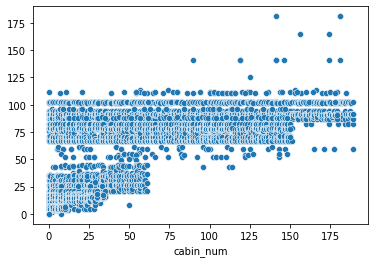

In [55]:
# imputation test for Cabin_num
cabinnum_imputed = np.zeros(len(train_data))

for idx, i in enumerate(train_data_cabinnum_median.index):
    #print(idx, train_data_cabinnum_median[idx:idx+1])
    index_list = train_data.index[(train_data['imputed_HomePlanet']==i[0]) & \
                                  (train_data['imputed_CryoSleep']==i[1]) & \
                                  (train_data['imputed_Destination']==i[2]) & \
                                  (train_data['imputed_cabindeck']==i[3]) & \
                                  (train_data['group_bool']==i[4]) & \
                                  (train_data['services_bool']==i[5])].to_list()
    impute_value = train_data_cabinnum_median[idx:idx+1]
    
    cabinnum_imputed[index_list] = impute_value
    
sns.scatterplot(train_data['cabin_num'], cabinnum_imputed)

In [56]:
cabinnum_blank_index = train_data.index[pd.isna(train_data['Cabin'])]
cabinnum_series = train_data['cabin_num']
print(pd.isna(train_data['Cabin']).sum())
cabinnum_series[cabinnum_blank_index] = cabinnum_imputed[cabinnum_blank_index]
print(pd.isna(cabinnum_series).sum())

train_data['imputed_cabinnum'] = cabinnum_series
print(train_data)

199
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  .

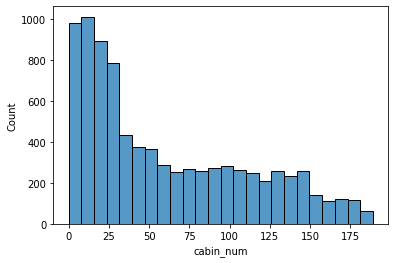

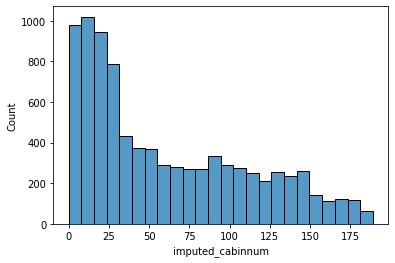

In [57]:
sns.histplot(train_data['cabin_num'])
plt.show()

sns.histplot(train_data['imputed_cabinnum'])
plt.show()

## Age imputation

In [58]:
train_data = train_data.loc[:,~train_data.columns.duplicated()]

In [59]:
train_data_age = (train_data[['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'imputed_cabinnum', 'imputed_under13yrs', 'group_bool', 'services_bool', 'Age']]).dropna(subset=['Age'])
print(train_data_age)
train_data_age_median = pd.DataFrame(train_data_age.groupby(['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'imputed_cabinnum', 'imputed_under13yrs', 'group_bool', 'services_bool']).median())

print(train_data_age_median)

     imputed_HomePlanet imputed_CryoSleep imputed_Destination  \
0                Europa             False         TRAPPIST-1e   
1                 Earth             False         TRAPPIST-1e   
2                Europa             False         TRAPPIST-1e   
3                Europa             False         TRAPPIST-1e   
4                 Earth             False         TRAPPIST-1e   
...                 ...               ...                 ...   
8688             Europa             False         55 Cancri e   
8689              Earth              True       PSO J318.5-22   
8690              Earth             False         TRAPPIST-1e   
8691             Europa             False         55 Cancri e   
8692             Europa             False         TRAPPIST-1e   

     imputed_cabindeck  imputed_cabinnum imputed_under13yrs  group_bool  \
0                    B               0.0              False       False   
1                    F               0.0              False       Fal

In [60]:
train_data_age_median.isnull().sum()

Age    0
dtype: int64

In [61]:
train_data_age_median_reset = train_data_age_median.reset_index()

#for idx, row in enumerate(train_data.index):
key_list = ['imputed_HomePlanet',
                    'imputed_CryoSleep',
                    'imputed_Destination',
                    'imputed_cabindeck',
                    'imputed_under13yrs',
                    'group_bool',
                    'services_bool']
cabinnum_nearest = np.zeros(len(train_data))

for idx in range(len(train_data)):
    i = [train_data.iloc[idx][i] for i in key_list]
    cabin_num_from_traindata = train_data.iloc[idx]['imputed_cabinnum']
    
    cabin_num_from_imputed = train_data_age_median_reset[(train_data_age_median_reset['imputed_HomePlanet']==i[0]) & \
                                                   (train_data_age_median_reset['imputed_CryoSleep']==i[1]) & \
                                                   (train_data_age_median_reset['imputed_Destination']==i[2]) & \
                                                   (train_data_age_median_reset['imputed_cabindeck']==i[3]) & \
                                                   (train_data_age_median_reset['imputed_under13yrs']==i[4]) & \
                                                   (train_data_age_median_reset['group_bool']==i[5]) & \
                                                   (train_data_age_median_reset['services_bool']==i[6])]['imputed_cabinnum']
    cabin_num_from_imputed = np.array(cabin_num_from_imputed)
    nearest_index = np.argmin(np.abs(np.array(cabin_num_from_imputed)-cabin_num_from_traindata))
    cabinnum_nearest[idx] = cabin_num_from_imputed[nearest_index]
    
print(Counter(cabinnum_nearest))
train_data['cabinnum_nearest'] = cabinnum_nearest

Counter({6.0: 169, 2.0: 167, 12.0: 159, 18.0: 156, 10.0: 155, 8.0: 153, 4.0: 140, 16.0: 129, 14.0: 129, 22.0: 125, 26.0: 123, 5.0: 119, 9.0: 118, 19.0: 117, 1.0: 116, 28.0: 116, 20.0: 114, 24.0: 111, 15.0: 109, 23.0: 109, 7.0: 102, 21.0: 100, 25.0: 100, 13.0: 98, 27.0: 98, 11.0: 94, 3.0: 93, 17.0: 88, 30.0: 87, 32.0: 84, 29.0: 83, 0.0: 79, 34.0: 72, 31.0: 68, 92.0: 64, 33.0: 62, 54.0: 57, 94.0: 56, 52.0: 56, 44.0: 55, 38.0: 54, 42.0: 53, 58.0: 52, 76.0: 51, 46.0: 50, 56.0: 50, 66.0: 50, 45.0: 48, 48.0: 48, 102.0: 48, 103.0: 47, 47.0: 47, 50.0: 46, 60.0: 46, 132.0: 46, 43.0: 44, 86.0: 44, 36.0: 43, 41.0: 43, 82.0: 42, 51.0: 42, 53.0: 42, 57.0: 42, 55.0: 41, 98.0: 41, 114.0: 41, 146.0: 41, 35.0: 40, 39.0: 40, 96.0: 40, 40.0: 39, 59.0: 39, 73.0: 39, 74.0: 39, 67.0: 38, 90.0: 38, 127.0: 38, 69.0: 37, 87.0: 37, 37.0: 37, 84.0: 37, 88.0: 37, 91.0: 36, 70.0: 36, 81.0: 36, 97.0: 36, 100.0: 36, 104.0: 36, 148.0: 36, 49.0: 35, 111.0: 35, 106.0: 35, 124.0: 35, 78.0: 34, 110.0: 34, 136.0: 34, 141.

<AxesSubplot:xlabel='Age'>

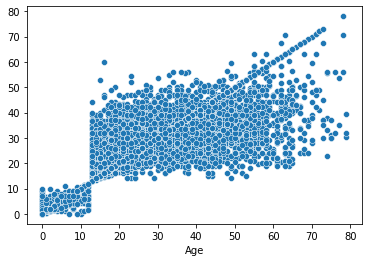

In [62]:
# imputation test for Cabin_num
age_imputed = np.zeros(len(train_data))

for idx, i in enumerate(train_data_age_median.index):
    #print(idx, train_data_cabinnum_median[idx:idx+1])
    index_list = train_data.index[(train_data['imputed_HomePlanet']==i[0]) & \
                                  (train_data['imputed_CryoSleep']==i[1]) & \
                                  (train_data['imputed_Destination']==i[2]) & \
                                  (train_data['imputed_cabindeck']==i[3]) & \
                                  (train_data['cabinnum_nearest']==i[4]) & \
                                  (train_data['imputed_under13yrs']==i[5]) & \
                                  (train_data['group_bool']==i[6]) & \
                                  (train_data['services_bool']==i[7])].to_list()
    #print(index_list)
    impute_value = train_data_age_median[idx:idx+1]
    
    age_imputed[index_list] = impute_value
    
sns.scatterplot(train_data['Age'], age_imputed)

In [63]:
Counter(pd.isna(age_imputed))

Counter({False: 8693})

In [64]:
age_blank_index = train_data.index[pd.isna(train_data['Age'])]
age_series = train_data['Age']
print(pd.isna(train_data['Age']).sum())
age_series[age_blank_index] = age_imputed[age_blank_index]
print(pd.isna(age_series).sum())

train_data['imputed_Age'] = age_series
print(train_data)

179
0
     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  .

## luxuary services imputation

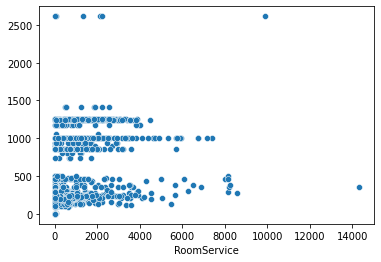

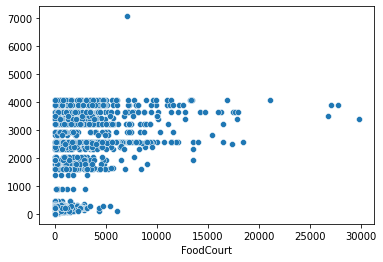

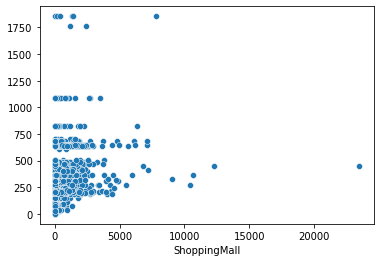

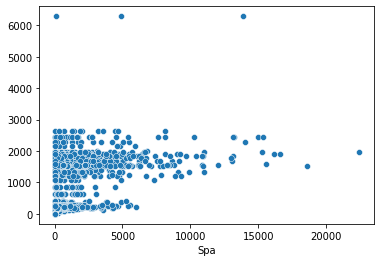

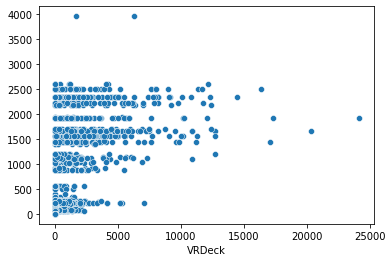

     PassengerId HomePlanet CryoSleep     Cabin    Destination   Age    VIP  \
0        0001_01     Europa     False     B/0/P    TRAPPIST-1e  39.0  False   
1        0002_01      Earth     False     F/0/S    TRAPPIST-1e  24.0  False   
2        0003_01     Europa     False     A/0/S    TRAPPIST-1e  58.0   True   
3        0003_02     Europa     False     A/0/S    TRAPPIST-1e  33.0  False   
4        0004_01      Earth     False     F/1/S    TRAPPIST-1e  16.0  False   
...          ...        ...       ...       ...            ...   ...    ...   
8688     9276_01     Europa     False    A/98/P    55 Cancri e  41.0   True   
8689     9278_01      Earth      True  G/1499/S  PSO J318.5-22  18.0  False   
8690     9279_01      Earth     False  G/1500/S    TRAPPIST-1e  26.0  False   
8691     9280_01     Europa     False   E/608/S    55 Cancri e  32.0  False   
8692     9280_02     Europa     False   E/608/S    TRAPPIST-1e  44.0  False   

      RoomService  FoodCourt  ShoppingMall  ...  im

In [65]:
service_list = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for service in service_list:
    #print('imputed_'+service)
    train_data_dummy = (train_data[['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'imputed_under13yrs', 'group_bool', 'services_bool', service]]).dropna(subset=[service])
    train_data_dummy_median = pd.DataFrame(train_data_dummy.groupby(['imputed_HomePlanet', 'imputed_CryoSleep', 'imputed_Destination', 'imputed_cabindeck', 'imputed_under13yrs', 'group_bool', 'services_bool']).mean())

    service_imputed = np.zeros(len(train_data))

    for idx, i in enumerate(train_data_dummy_median.index):
        #print(idx, train_data_cabinnum_median[idx:idx+1])
        index_list = train_data.index[(train_data['imputed_HomePlanet']==i[0]) & \
                                      (train_data['imputed_CryoSleep']==i[1]) & \
                                      (train_data['imputed_Destination']==i[2]) & \
                                      (train_data['imputed_cabindeck']==i[3]) & \
                                      (train_data['imputed_under13yrs']==i[4]) & \
                                      (train_data['group_bool']==i[5]) & \
                                      (train_data['services_bool']==i[6])].to_list()
        #print(index_list)
        impute_value = train_data_dummy_median[idx:idx+1]

        service_imputed[index_list] = impute_value

    sns.scatterplot(train_data[service], service_imputed)
    plt.show()
    
    service_blank_index = train_data.index[pd.isna(train_data[service])]
    service_series = train_data[service]
    service_series[service_blank_index] = service_imputed[service_blank_index]

    train_data['imputed_'+service] = service_series

print(train_data)

# output to csv

In [66]:
train_data.to_csv('train_data_imputed.csv')

## explore

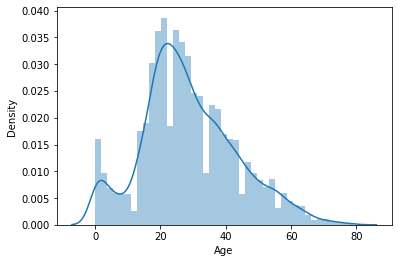

[(0.0, 181), (1.0, 73), (1.5, 1), (2.0, 77), (2.5, 1), (3.0, 76), (4.0, 73), (4.5, 1), (5.0, 35), (6.0, 42), (7.0, 54), (8.0, 47), (9.0, 45), (10.0, 42), (11.0, 50), (12.0, 42), (13.0, 141), (14.0, 138), (15.0, 156), (16.0, 147), (16.5, 1), (17.0, 158), (18.0, 326), (18.5, 1), (19.0, 296), (19.5, 1), (20.0, 279), (20.5, 2), (21.0, 317), (21.5, 3), (22.0, 296), (23.0, 293), (23.5, 2), (24.0, 332), (25.0, 247), (25.5, 1), (26.0, 277), (26.5, 5), (27.0, 264), (27.5, 1), (28.0, 269), (28.5, 2), (29.0, 232), (30.0, 191), (31.0, 203), (32.0, 203), (32.5, 2), (33.0, 180), (33.5, 1), (34.0, 151), (34.5, 2), (35.0, 175), (35.5, 1), (36.0, 180), (36.5, 1), (37.0, 179), (38.0, 164), (38.5, 2), (39.0, 139), (39.5, 1), (40.0, 130), (40.5, 1), (41.0, 132), (41.5, 1), (42.0, 122), (42.5, 5), (43.0, 132), (44.0, 117), (45.0, 91), (46.0, 97), (47.0, 89), (48.0, 72), (49.0, 84), (50.0, 76), (51.0, 59), (52.0, 52), (53.0, 62), (54.0, 67), (55.0, 69), (55.5, 1), (56.0, 48), (57.0, 47), (58.0, 47), (59.0, 

In [67]:
sns.distplot(train_data['Age'])
plt.show()

print(sorted(Counter(train_data[train_data['Age'].notnull()]['Age']).items()))

# it is important characteristic.
# age has two peaks. from zero to 12, and from 13 to the end.
# so the new variable that indicates the passenger is under 13 or not is usefull.

train_data['under13_bool'] = train_data[train_data['Age'].notnull()]['Age'] < 13

In [68]:
print((Counter(train_data[train_data['under13_bool']==True]['HomePlanet'])))
print((Counter(train_data[train_data['under13_bool']==False]['HomePlanet'])))

Counter({'Earth': 603, 'Mars': 175, 'Europa': 45, nan: 17})
Counter({'Earth': 3999, 'Europa': 2086, 'Mars': 1584, nan: 184})


In [69]:
# missing data count if age is missing
train_data[train_data['Age'].isnull()].isnull().sum()

PassengerId             0.0
HomePlanet              0.0
CryoSleep               0.0
Cabin                   0.0
Destination             0.0
Age                     0.0
VIP                     0.0
RoomService             0.0
FoodCourt               0.0
ShoppingMall            0.0
Spa                     0.0
VRDeck                  0.0
Name                    0.0
Transported             0.0
RoomService_log         0.0
FoodCourt_log           0.0
ShoppingMall_log        0.0
Spa_log                 0.0
VRDeck_log              0.0
ServiceSum              0.0
RoomService_bool        0.0
FoodCourt_bool          0.0
ShoppingMall_bool       0.0
Spa_bool                0.0
VRDeck_bool             0.0
num_services            0.0
services_bool           0.0
group_id                0.0
secondId                0.0
member_num              0.0
group_bool              0.0
under13yrs              0.0
cabin_deck              0.0
cabin_num               0.0
cabin_side              0.0
imputed_CryoSleep   

In [70]:
test_data[train_data['Age'].isnull()].isnull().sum()

PassengerId          0.0
HomePlanet           0.0
CryoSleep            0.0
Cabin                0.0
Destination          0.0
Age                  0.0
VIP                  0.0
RoomService          0.0
FoodCourt            0.0
ShoppingMall         0.0
Spa                  0.0
VRDeck               0.0
Name                 0.0
Transported          0.0
RoomService_log      0.0
FoodCourt_log        0.0
ShoppingMall_log     0.0
Spa_log              0.0
VRDeck_log           0.0
ServiceSum           0.0
RoomService_bool     0.0
FoodCourt_bool       0.0
ShoppingMall_bool    0.0
Spa_bool             0.0
VRDeck_bool          0.0
num_services         0.0
services_bool        0.0
group_id             0.0
secondId             0.0
member_num           0.0
group_bool           0.0
under13yrs           0.0
dtype: float64

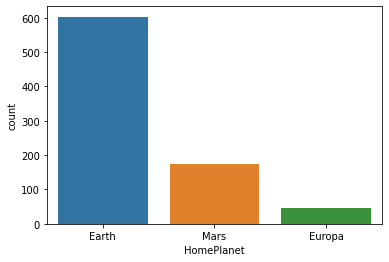

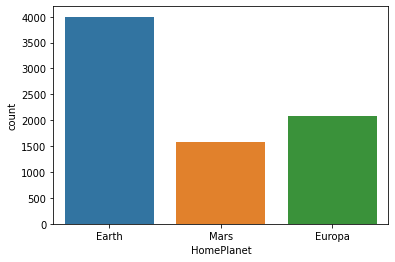

In [71]:
planet_order_list = ['Earth', 'Mars', 'Europa']

sns.countplot(train_data[train_data['Age']<13]['HomePlanet'], order=planet_order_list)
plt.show()

sns.countplot(train_data[train_data['Age']>=13]['HomePlanet'], order=planet_order_list)
plt.show()

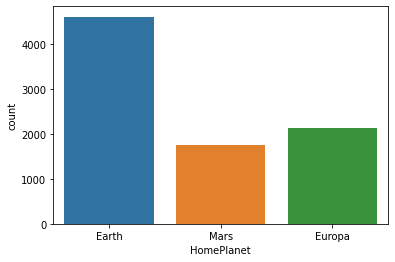

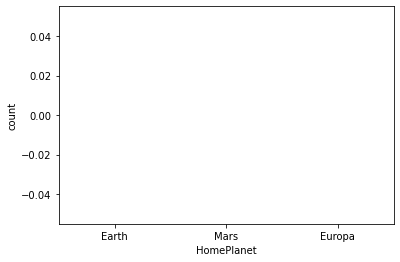

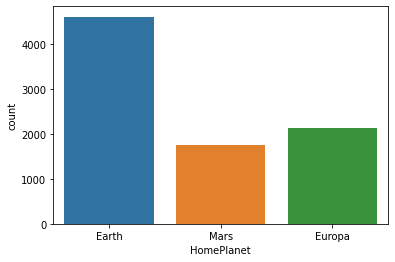

In [72]:
# homeplanet distribution for all passengers
sns.countplot(train_data['HomePlanet'], order=planet_order_list)
plt.show()

# homeplanet distribution for agi is missing.
sns.countplot(train_data[train_data['Age'].isnull()]['HomePlanet'], order=planet_order_list)
plt.show()

# homeplanet distribution for agi is NOT missing.
sns.countplot(train_data[train_data['Age'].notnull()]['HomePlanet'], order=planet_order_list)
plt.show()

<AxesSubplot:xlabel='Age', ylabel='Count'>

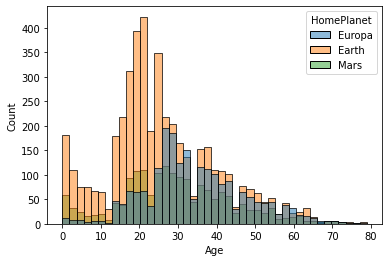

In [73]:
sns.histplot(data=train_data, x='Age', hue='HomePlanet')

# age distribution is different between home planet, it is super important!

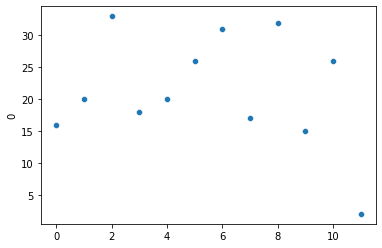

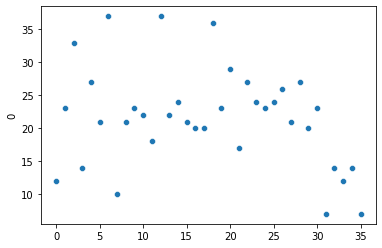

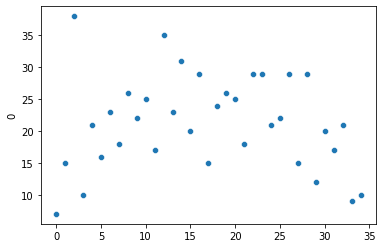

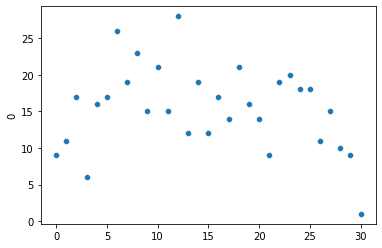

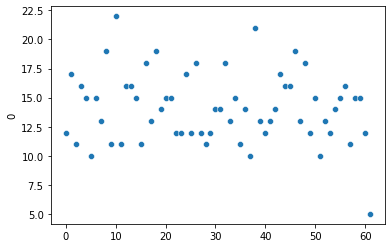

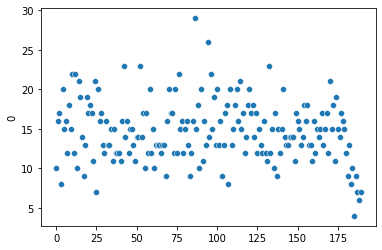

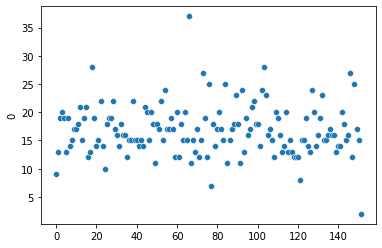

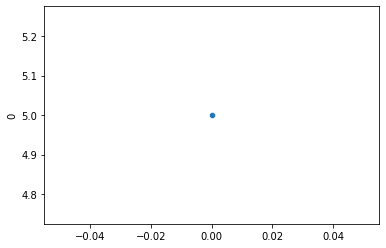

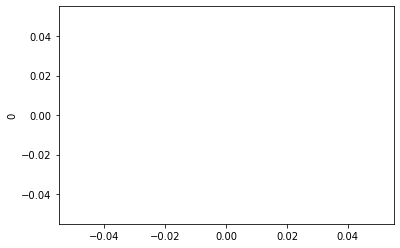

In [74]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']

#cabinnum_test = pd.DataFrame.from_dict(Counter(cabin_df[cabin_df['cabin_deck']=='G']['cabin_num']), orient = "index")
#print(cabinnum_test)

#sns.scatterplot(x=cabinnum_test.index, y=cabinnum_test[0])
for x in cabin_order_list:
    cabinnum_test = pd.DataFrame.from_dict(Counter(cabin_df[cabin_df['cabin_deck']==x]['cabin_num']), orient = "index")
    sns.scatterplot(x=cabinnum_test.index, y=cabinnum_test[0])
    plt.show()

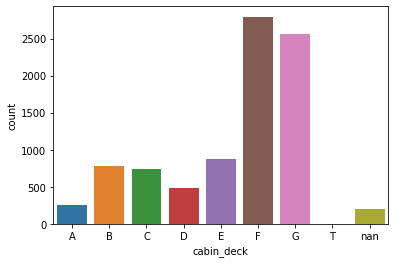

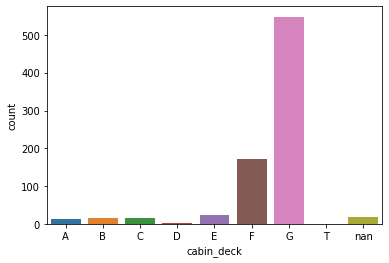

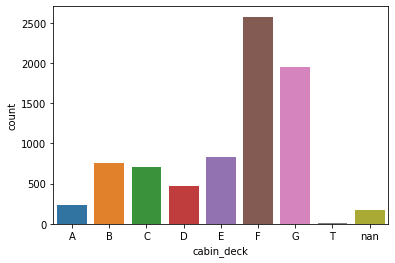

In [75]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']

sns.countplot(cabin_df['cabin_deck'], order=cabin_order_list)
plt.show()

sns.countplot(cabin_df[cabin_df['Age']<13]['cabin_deck'], order=cabin_order_list)
plt.show()

sns.countplot(cabin_df[cabin_df['Age']>=13]['cabin_deck'], order=cabin_order_list)
plt.show()

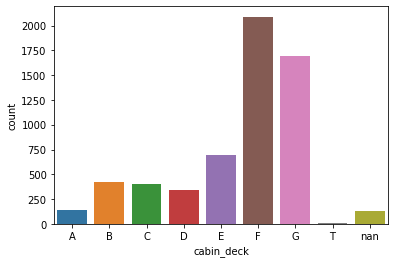

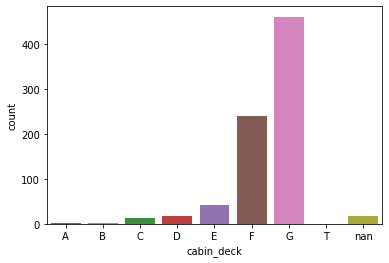

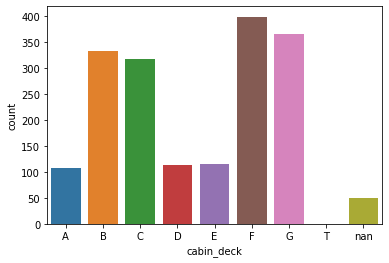

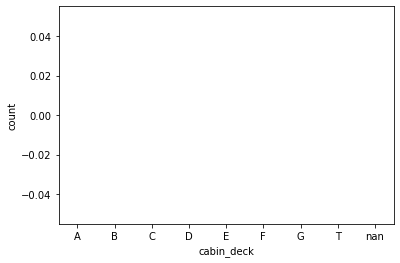

In [76]:
cabin_order_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'nan']
destination_order_list = ['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', 'nan']

for d in destination_order_list:
    sns.countplot(cabin_df[train_data['Destination']==d]['cabin_deck'], order=cabin_order_list)
    plt.show()

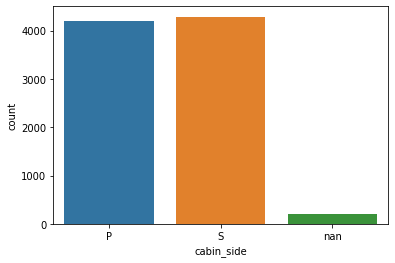

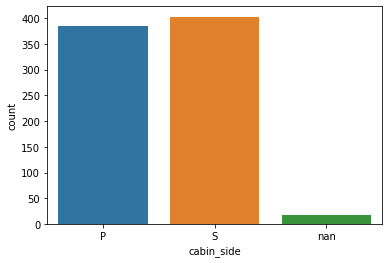

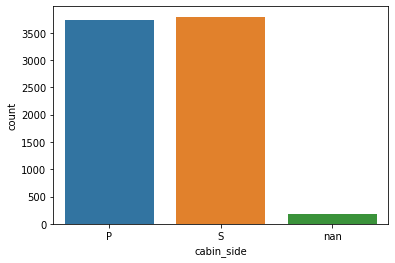

In [77]:
side_order_list = ['P', 'S', 'nan']

sns.countplot(cabin_df['cabin_side'], order=side_order_list)
plt.show()

sns.countplot(cabin_df[cabin_df['Age']<13]['cabin_side'], order=side_order_list)
plt.show()

sns.countplot(cabin_df[cabin_df['Age']>=13]['cabin_side'], order=side_order_list)
plt.show()

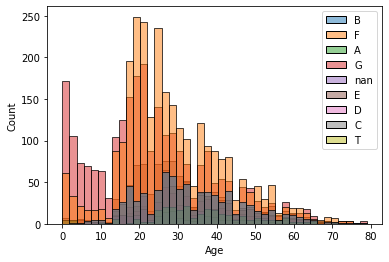

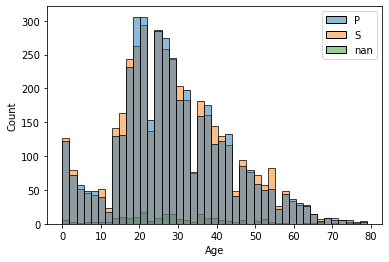

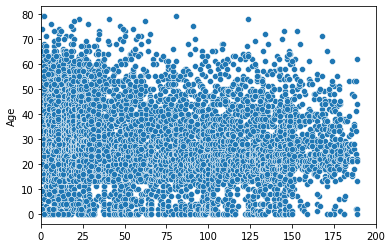

In [78]:
sns.histplot(data=train_data, x='Age', hue=cabin_deck)
plt.show()

sns.histplot(data=train_data, x='Age', hue=cabin_side)
plt.show()

sns.scatterplot(data=train_data, y='Age', x=cabin_num)
plt.xlim(0, 200)
plt.show()

# cabin-deck has effect on age distribution!
# cabin-side has no effect on age distribution.

In [79]:
Counter(train_data['Destination'])

Counter({'TRAPPIST-1e': 5915,
         'PSO J318.5-22': 796,
         '55 Cancri e': 1800,
         nan: 182})

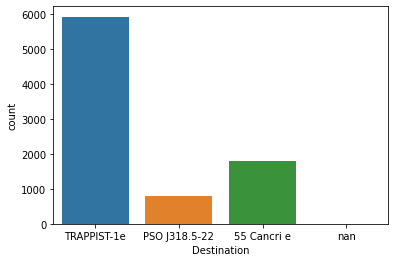

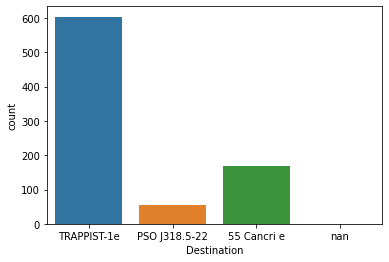

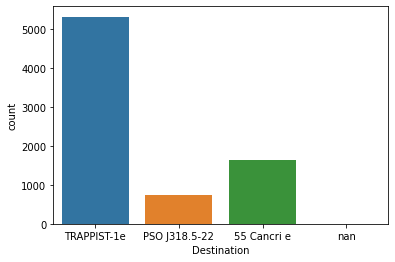

In [80]:
destination_order_list = ['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', 'nan']

sns.countplot(train_data['Destination'], order=destination_order_list)
plt.show()

sns.countplot(train_data[train_data['Age']<13]['Destination'], order=destination_order_list)
plt.show()

sns.countplot(train_data[train_data['Age']>=13]['Destination'], order=destination_order_list)
plt.show()

<AxesSubplot:xlabel='Age', ylabel='Count'>

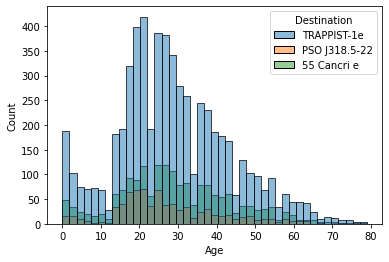

In [81]:
sns.histplot(data=train_data, x='Age', hue='Destination')
# destination has no effect on age distribution

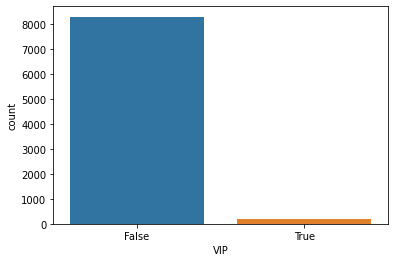

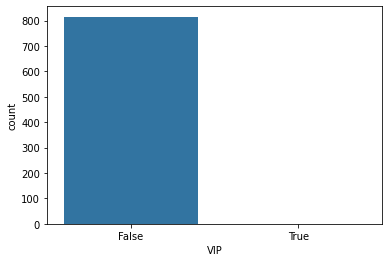

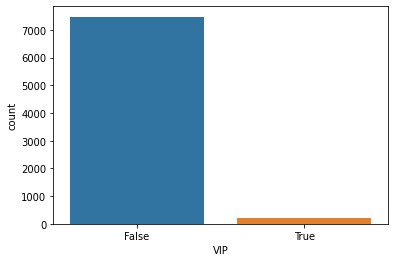

In [82]:
vip_order_list = [False, True]

sns.countplot(train_data['VIP'], order=vip_order_list)
plt.show()

sns.countplot(train_data[train_data['Age']<13]['VIP'], order=vip_order_list)
plt.show()

sns.countplot(train_data[train_data['Age']>=13]['VIP'], order=vip_order_list)
plt.show()

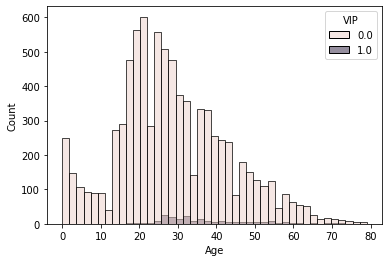

<AxesSubplot:xlabel='Age', ylabel='Count'>

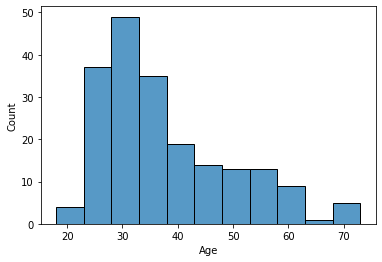

In [83]:
sns.histplot(data=train_data, x='Age', hue='VIP')
plt.show()
# destination has no effect on age distribution

sns.histplot(data=train_data[train_data['VIP']==True], x='Age')
# VIP has effect on age disribution.

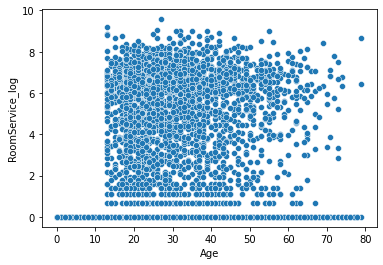

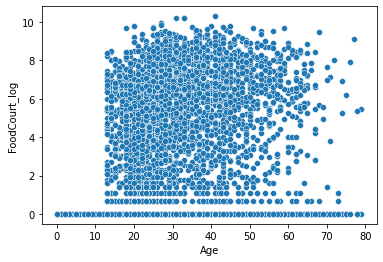

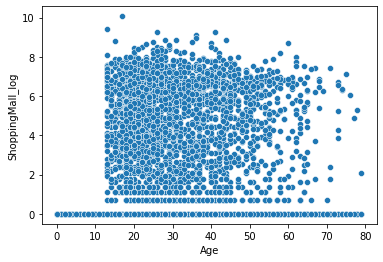

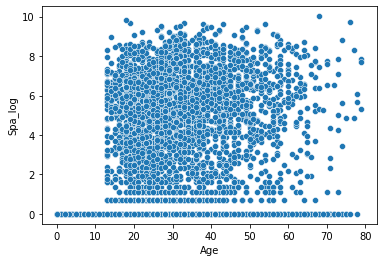

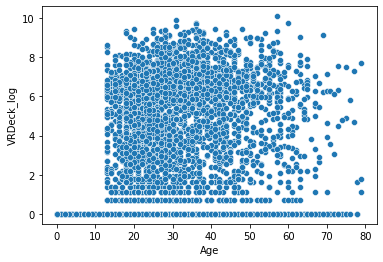

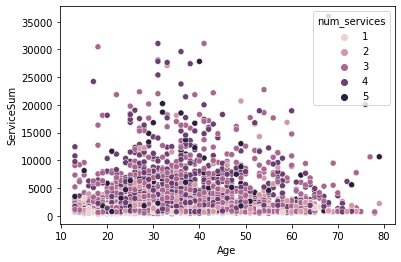

In [84]:
# RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

sns.scatterplot(data=train_data, y='RoomService_log', x='Age')
plt.show()
sns.scatterplot(data=train_data, y='FoodCourt_log', x='Age')
plt.show()
sns.scatterplot(data=train_data, y='ShoppingMall_log', x='Age')
plt.show()
sns.scatterplot(data=train_data, y='Spa_log', x='Age')
plt.show()
sns.scatterplot(data=train_data, y='VRDeck_log', x='Age')
plt.show()
sns.scatterplot(data=train_data[train_data['num_services']>0], y='ServiceSum', x='Age', hue='num_services')
plt.show()

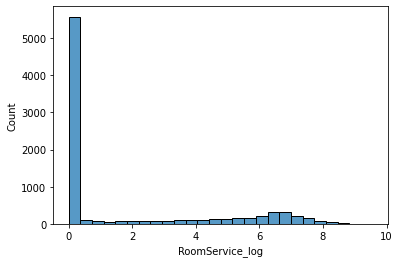

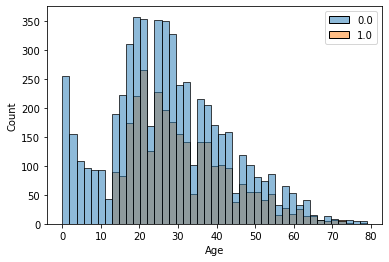

In [85]:
# RoomService, FoodCourt, ShoppingMall, Spa, VRDeck
sns.histplot(data=train_data, x='RoomService_log')
plt.show()

RoomService_binning = np.zeros(len(train_data))
RoomService_binning[train_data.index[train_data['RoomService_log']>0]] = 1
#RoomService_binning[train_data.index[train_data['RoomService_log']>3]] = 2
#RoomService_binning[train_data.index[train_data['RoomService_log']>6]] = 3
#RoomService_binning[train_data.index[train_data['RoomService_log']>8]] = 4

sns.histplot(data=train_data, x='Age', hue=RoomService_binning)
plt.show()

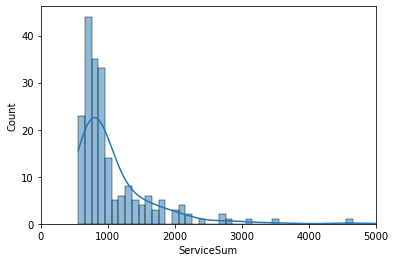

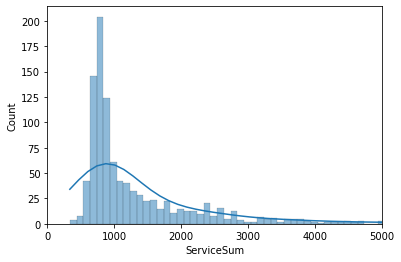

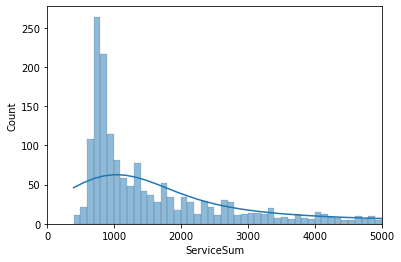

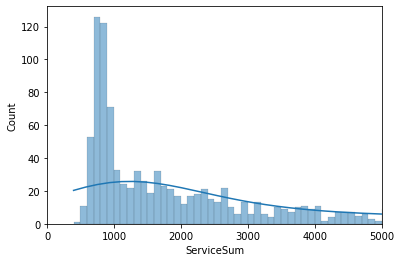

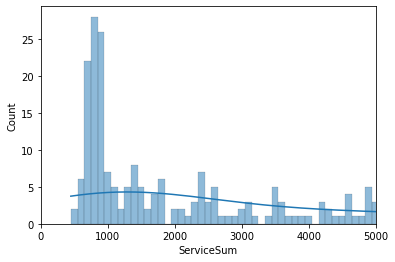

In [86]:
for i in range(5):
    sns.histplot(data=train_data[train_data['num_services']==i+1], x='ServiceSum', binwidth=100, kde=True)
    plt.xlim(0, 5000)
    plt.show()

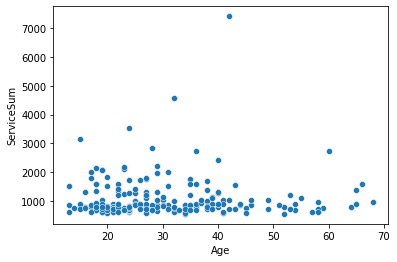

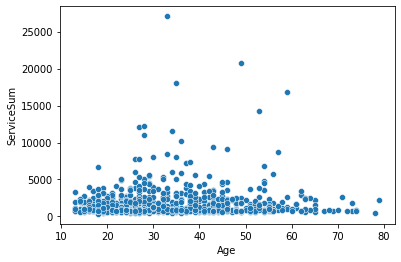

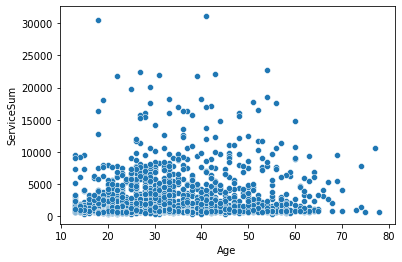

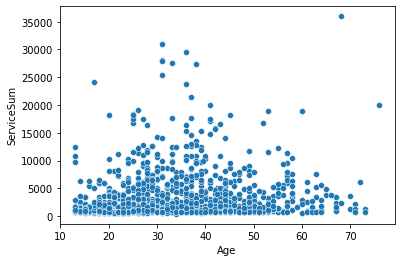

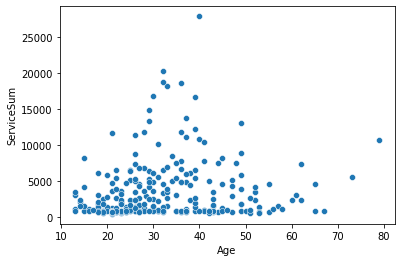

In [87]:
for i in range(5):
    sns.scatterplot(data=train_data[train_data['num_services']==i+1], y='ServiceSum', x = 'Age')
    plt.show()

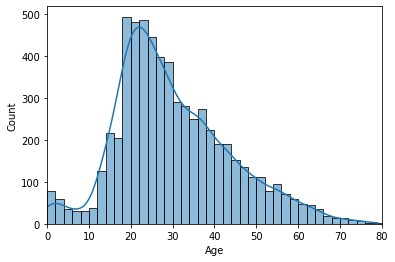

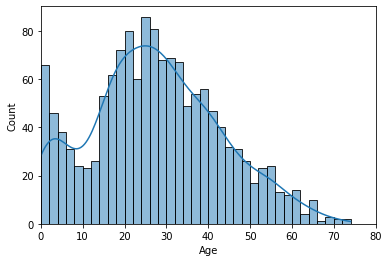

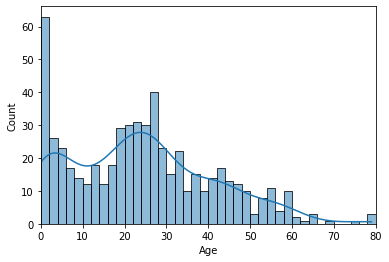

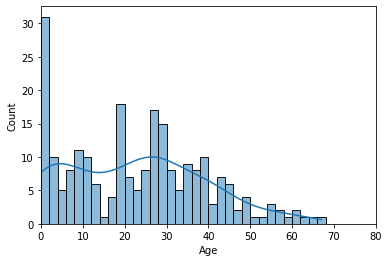

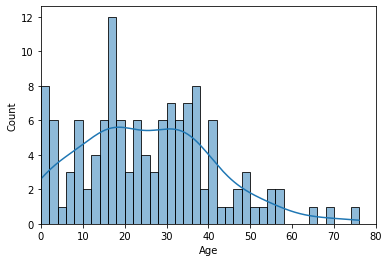

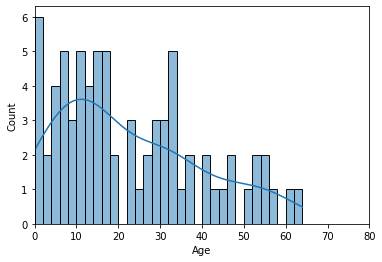

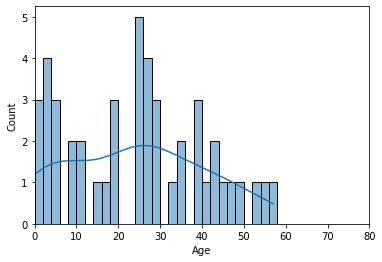

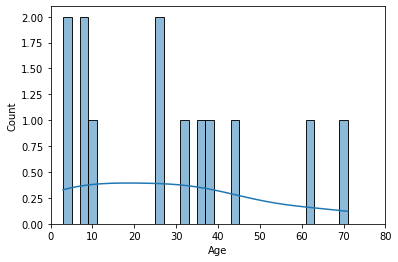

In [88]:
secondId_list = train_data['secondId'].unique()

for i in secondId_list:
    sns.histplot(data=train_data[train_data['secondId']==i], x='Age', binwidth=2, kde=True)
    plt.xlim(0, 80)
    plt.show()

In [89]:
train_data = pd.concat([train_data, cabin_df.drop('Age', axis=1)], axis=1)
train_data

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,imputed_Age,imputed_RoomService,imputed_FoodCourt,imputed_ShoppingMall,imputed_Spa,imputed_VRDeck,under13_bool,cabin_deck,cabin_num,cabin_side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,39.0,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,24.0,109.0,9.0,25.0,549.0,44.0,False,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,58.0,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,33.0,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,16.0,303.0,70.0,151.0,565.0,2.0,False,F,0.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,...,41.0,0.0,6819.0,0.0,1643.0,74.0,False,A,10.0,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,...,18.0,0.0,0.0,0.0,0.0,0.0,False,G,150.0,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,...,26.0,0.0,0.0,1872.0,1.0,0.0,False,G,150.0,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,...,32.0,0.0,1049.0,0.0,353.0,3235.0,False,E,61.0,S
